# ADNI External Validation, Full Independent Longitudinal Multimodal Reliability

This notebook is the independent ADNI implementation of the completed OASIS-3 analysis.

## Scientific question

> **Does disagreement between learned MRI and clinical views of a patient's evolving state identify predictive unreliability in an independent ADNI cohort?**

The frozen MRI representation is transferred across datasets, but all longitudinal prediction heads, preprocessing, outer splits, and reliability analyses are estimated independently on ADNI.

## Full workflow

```text
Downloaded ADNI DICOM
        ↓
DICOM series manifest
        ↓
one 3D T1 MP-RAGE series per subject × study
        ↓
ADNI longitudinal clinical tables
        ↓
MRI / clinical anchor matching
        ↓
future MMSE cohort, 180–730 days
        ↓
DICOM → NIfTI
        ↓
same 96³ raw-T1 preprocessing as OASIS
        ↓
frozen Triad-SwinB-SimMIM
        ↓
1488-D embedding per MRI session
        ↓
longitudinal MRI + clinical histories
        ↓
same temporal / gated multimodal architecture
        ↓
6 repeated subject-disjoint outer splits
        ↓
MRI-only / Clinical-only / Gated-joint / Persistence
        ↓
prediction disagreement
+ latent disagreement
+ ensemble uncertainty
+ within-view spread
        ↓
prediction-error association
+ difficulty-adjusted association
+ secondary large-error detection
+ selective prediction
+ OASIS ↔ ADNI replication summary
```

## Important independence rule

The only transferred model is the frozen Triad MRI foundation representation. ADNI does **not** reuse OASIS-trained prediction heads, PCA/scalers, or train/test assignments.

The notebook is resumable and avoids keeping a bulky 96³ preprocessing cache. NIfTI files can be deleted automatically after their embeddings are successfully saved.


In [1]:
# ============================================================
# 0. CONFIGURATION, IMPORTS, DEVICE
# ============================================================

from pathlib import Path
import os
import re
import sys
import gc
import json
import math
import random
import hashlib
import shutil
import subprocess
import warnings
import time
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

ADNI_ROOT = Path(r"C:\Projects\OASIS\ADNI")

OASIS_PROJECT_ROOT = Path(
    r"C:\Projects\OASIS\oasis_raw_t1_encoder"
)

TRIAD_MODEL_ROOT = Path(
    r"C:\Projects\OASIS\models"
)

TRIAD_REPO = (
    TRIAD_MODEL_ROOT / "Triad"
)

TRIAD_CKPT = (
    TRIAD_MODEL_ROOT
    / "Triad-SwinB-SimMIM.pth"
)

PREP_ROOT = (
    ADNI_ROOT / "prep"
)

MANIFEST_DIR = (
    PREP_ROOT / "manifests"
)

CLINICAL_DIR = (
    PREP_ROOT / "clinical"
)

NIFTI_DIR = (
    PREP_ROOT / "nifti"
)

EMBED_ROOT = (
    PREP_ROOT / "triad_embeddings"
)

QC_DIR = (
    PREP_ROOT / "qc"
)

PAPER_ROOT = (
    ADNI_ROOT / "PAPER_READY_FINAL_RESULTS"
)

REPEAT_DIR = (
    PAPER_ROOT / "outer_repeats"
)

for d in [
    PREP_ROOT,
    MANIFEST_DIR,
    CLINICAL_DIR,
    NIFTI_DIR,
    EMBED_ROOT,
    QC_DIR,
    PAPER_ROOT,
    REPEAT_DIR,
]:
    d.mkdir(
        parents=True,
        exist_ok=True,
    )

# ------------------------------------------------------------
# DATASET / MODEL CONFIG
# ------------------------------------------------------------

TARGET_SHAPE = (
    96,
    96,
    96,
)

EXPECTED_EMBED_DIM = 1488

MRI_CLINICAL_MATCH_WINDOW_DAYS = 180

MIN_FUTURE_DAYS = 180
MAX_FUTURE_DAYS = 730

MAX_MRI_HISTORY = 6
MAX_CLINICAL_HISTORY = 8

CLINICAL_FEATURES = [
    "mmse",
    "cdrsb",
    "cdr_global",
    "age_visit",
]

PCA_DIM_RAW = 64

TEMPORAL_HIDDEN = 32

BATCH_SIZE = 16

MAX_EPOCHS = 50
PATIENCE = 8

LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-4

OUTER_TEST_SIZE = 0.20

N_OUTER_REPEATS = 6
N_INNER_FOLDS = 5

N_OOF_MEMBERS = 2
N_TEST_MEMBERS = 3

INNER_VALID_FRACTION = 0.15

FIXED_LARGE_ERROR_THRESHOLD = 2.0

ERROR_MODEL_ALPHA = 10.0

COVERAGES = np.array([
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
    1.00,
])

# This keeps disk use low.
DELETE_NIFTI_AFTER_EMBEDDING = True

print("ADNI:", ADNI_ROOT)
print("Triad repo:", TRIAD_REPO)
print("Triad checkpoint:", TRIAD_CKPT)
print("Embedding output:", EMBED_ROOT)
print("Paper output:", PAPER_ROOT)


ADNI: C:\Projects\OASIS\ADNI
Triad repo: C:\Projects\OASIS\models\Triad
Triad checkpoint: C:\Projects\OASIS\models\Triad-SwinB-SimMIM.pth
Embedding output: C:\Projects\OASIS\ADNI\prep\triad_embeddings
Paper output: C:\Projects\OASIS\ADNI\PAPER_READY_FINAL_RESULTS


In [2]:
# ============================================================
# 1. DEPENDENCY CHECK
# ============================================================

import importlib.util

required_python = [
    ("pydicom", "pydicom"),
    ("nibabel", "nibabel"),
    ("scipy", "scipy"),
    ("sklearn", "scikit-learn"),
    ("torch", "torch"),
    ("monai", "monai"),
]

missing = []

for module_name, package_name in required_python:
    ok = (
        importlib.util.find_spec(
            module_name
        )
        is not None
    )

    print(
        f"{package_name:20s}",
        "OK" if ok else "MISSING",
    )

    if not ok:
        missing.append(
            package_name
        )

if missing:
    print(
        "\nInstall missing packages in the active notebook kernel:"
    )
    print(
        "%pip install "
        + " ".join(missing)
    )

DCM2NIIX = (
    shutil.which("dcm2niix")
    or shutil.which("dcm2niix.exe")
)

print(
    "\ndcm2niix:",
    DCM2NIIX
    if DCM2NIIX
    else "NOT FOUND",
)

if not ADNI_ROOT.exists():
    raise FileNotFoundError(
        f"ADNI root does not exist:\n{ADNI_ROOT}"
    )

if not TRIAD_REPO.exists():
    raise FileNotFoundError(
        f"Triad repository not found:\n{TRIAD_REPO}"
    )

if not TRIAD_CKPT.exists():
    raise FileNotFoundError(
        f"Triad checkpoint not found:\n{TRIAD_CKPT}"
    )


pydicom              OK
nibabel              OK
scipy                OK
scikit-learn         OK
torch                OK
monai                OK

dcm2niix: C:\Users\Neehar\AppData\Roaming\Python\Python314\Scripts\dcm2niix.EXE


In [3]:
# ============================================================
# 2. PYTORCH + REPRODUCIBILITY
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import (
    Dataset,
    DataLoader,
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

def seed_everything(
    seed: int,
):
    seed = int(seed)

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_everything(
    SEED
)

print(
    "PyTorch:",
    torch.__version__,
)

print(
    "Device:",
    DEVICE,
)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )


PyTorch: 2.11.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 3. Reuse the completed ADNI DICOM selection

The earlier preparation run scanned all 345,580 DICOM files and created the selected series manifest. This notebook **loads that manifest directly**.

That is intentional. Do not rescan the 10 batches unless the selected manifest is missing.


In [4]:
# ============================================================
# 3. LOAD SELECTED MRI SERIES
# ============================================================

SELECTED_DICOM_MANIFEST = (
    MANIFEST_DIR
    / "adni_selected_t1_series.csv"
)

if not SELECTED_DICOM_MANIFEST.exists():
    raise FileNotFoundError(
        "The completed DICOM selection manifest was not found:\n"
        f"{SELECTED_DICOM_MANIFEST}\n\n"
        "Run the ADNI pre-pipeline DICOM scan/selection first."
    )

selected = pd.read_csv(
    SELECTED_DICOM_MANIFEST,
    low_memory=False,
)

required_columns = [
    "subject_id",
    "study_uid",
    "series_uid",
    "visit_date",
    "n_files",
    "rows",
    "cols",
    "slice_thickness",
    "example_path_1",
]

missing = [
    c
    for c in required_columns
    if c not in selected.columns
]

if missing:
    raise KeyError(
        f"Selected MRI manifest is missing columns: {missing}"
    )

selected["subject_id"] = (
    selected["subject_id"]
    .astype(str)
    .str.upper()
)

selected["visit_date"] = pd.to_datetime(
    selected["visit_date"],
    errors="coerce",
)

selected = (
    selected
    .dropna(
        subset=[
            "subject_id",
            "visit_date",
        ]
    )
    .sort_values(
        [
            "subject_id",
            "visit_date",
            "study_uid",
        ]
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("SELECTED ADNI MRI SERIES")
print("=" * 80)
print("Series:", len(selected))
print(
    "Subjects:",
    selected["subject_id"].nunique(),
)
print(
    "Longitudinal subjects:",
    int(
        (
            selected
            .groupby("subject_id")
            .size()
            .gt(1)
        ).sum()
    ),
)

display(
    selected[
        [
            "subject_id",
            "visit_date",
            "study_uid",
            "series_uid",
            "series_description",
            "protocol_name",
            "sequence_name",
            "n_files",
            "rows",
            "cols",
            "slice_thickness",
            "example_path_1",
        ]
    ].head(30)
)


SELECTED ADNI MRI SERIES
Series: 1945
Subjects: 401
Longitudinal subjects: 340


,subject_id,visit_date,study_uid,series_uid,series_description,protocol_name,sequence_name,n_files,rows,cols,slice_thickness,example_path_1
0,002_S_0295,1970-01-01 00:00:00.020060418,2.16.124.113543.6006.99.0913682119657460455,2.16.124.113543.6006.99.05123285625534359746,MP-RAGE,ADNI 12M4 TS/2,NaN,166,256,256,1.2,C:\Projects\OASIS\ADNI\p6\ADNI\002_S_0295\MP-R...
1,002_S_0295,1970-01-01 00:00:00.020061102,2.16.124.113543.6006.99.06736997866941757259,2.16.124.113543.6006.99.6140400899638574745,MP-RAGE,ADNI 12M4 TS/2,NaN,166,256,256,1.2,C:\Projects\OASIS\ADNI\p9\ADNI\002_S_0295\MP-R...
2,002_S_0295,1970-01-01 00:00:00.020070525,2.16.124.113543.6006.99.06923367135824137775,2.16.124.113543.6006.99.6052213731909918407,MP-RAGE,ADNI 12M4 TS/2,NaN,166,256,256,1.2,C:\Projects\OASIS\ADNI\p1\002_S_0295\MP-RAGE\2...
3,002_S_0295,1970-01-01 00:00:00.020080723,2.16.124.113543.6006.99.7653101050947582074,2.16.124.113543.6006.99.6491357281857161083,MP-RAGE,ADNI 12M4 TS/2,NaN,166,256,256,1.2,C:\Projects\OASIS\ADNI\p8\ADNI\002_S_0295\MP-R...
4,002_S_0295,1970-01-01 00:00:00.020090522,2.16.124.113543.6006.99.7555896319141425655,2.16.124.113543.6006.99.02317122787392851656,MP-RAGE,ADNI 12M4TS PATIENT/2,NaN,166,256,256,1.2,C:\Projects\OASIS\ADNI\p1\002_S_0295\MP-RAGE\2...
5,002_S_0295,1970-01-01 00:00:00.020100513,2.16.124.113543.6006.99.4999618768177193185,2.16.124.113543.6006.99.08599028431928506357,MP-RAGE,ADNI 12M4TS PATIENT/2,NaN,166,256,256,1.2,C:\Projects\OASIS\ADNI\p1\002_S_0295\MP-RAGE\2...
6,002_S_0413,1970-01-01 00:00:00.020060502,2.16.124.113543.6006.99.3658447610609593990,2.16.124.113543.6006.99.3661462910275302521,MP-RAGE,ADNI 12M4 TS/2,NaN,166,256,256,1.2,C:\Projects\OASIS\ADNI\p6\ADNI\002_S_0413\MP-R...
7,002_S_0413,1970-01-01 00:00:00.020061115,2.16.124.113543.6006.99.4870314235674525298,2.16.124.113543.6006.99.7142813739810582547,MP-RAGE,ADNI 12M4 TS/2,NaN,166,256,256,1.2,C:\Projects\OASIS\ADNI\p3\ADNI\002_S_0413\MP-R...
8,002_S_0413,1970-01-01 00:00:00.020070601,2.16.124.113543.6006.99.3009347355024110763,2.16.124.113543.6006.99.01998927098024443306,MP-RAGE,ADNI 12M4 TS/2,NaN,166,256,256,1.2,C:\Projects\OASIS\ADNI\p2\ADNI\002_S_0413\MP-R...
9,002_S_0413,1970-01-01 00:00:00.020080731,2.16.124.113543.6006.99.07886985097326109548,2.16.124.113543.6006.99.4580850590036426308,MP-RAGE,ADNI 12M4 TS/2,NaN,166,256,256,1.2,C:\Projects\OASIS\ADNI\p7\ADNI\002_S_0413\MP-R...


## 4. Standardize ADNI clinical tables

The downloaded ADNI export contains separate MMSE, CDR, DXSUM and PTDEMOG files. ADNIMERGE is not required.

The clinical history used by the downstream model is:

```text
MMSE
CDR-SB
global CDR
age at visit
```

Diagnosis and demographic variables are retained for QC and future extensions, but diagnosis is not fed into the prediction model.


In [5]:
# ============================================================
# 4. LOCATE CLINICAL FILES
# ============================================================

all_csvs = sorted(
    ADNI_ROOT.rglob("*.csv")
)

def find_named_csv(
    exact_names=(),
    regexes=(),
):
    candidates = []

    exact_upper = {
        x.upper()
        for x in exact_names
    }

    for p in all_csvs:

        name = p.name.upper()

        if name in exact_upper:
            candidates.append(p)
            continue

        if any(
            re.search(
                pattern,
                name,
                flags=re.I,
            )
            for pattern in regexes
        ):
            candidates.append(p)

    if not candidates:
        return None

    # Prefer Assessments for clinical files.
    candidates = sorted(
        candidates,
        key=lambda p: (
            "ASSESSMENTS" not in str(p).upper(),
            len(str(p)),
        )
    )

    return candidates[0]

MMSE_FILE = find_named_csv(
    exact_names=[
        "MMSE_30Aug2026.csv",
    ],
    regexes=[
        r"^MMSE.*\.CSV$",
    ],
)

CDR_FILE = find_named_csv(
    exact_names=[
        "CDR_30Aug2026.csv",
    ],
    regexes=[
        r"^CDR.*\.CSV$",
    ],
)

DXSUM_FILE = find_named_csv(
    exact_names=[
        "DXSUM_30Aug2026.csv",
    ],
    regexes=[
        r"DXSUM",
    ],
)

PTDEMOG_FILE = find_named_csv(
    exact_names=[
        "PTDEMOG_30Aug2026.csv",
    ],
    regexes=[
        r"PTDEMOG",
    ],
)

print("MMSE:", MMSE_FILE)
print("CDR:", CDR_FILE)
print("DXSUM:", DXSUM_FILE)
print("PTDEMOG:", PTDEMOG_FILE)

if MMSE_FILE is None:
    raise FileNotFoundError(
        "Could not locate the ADNI MMSE CSV."
    )


MMSE: C:\Projects\OASIS\ADNI\Assessments\MMSE_30Aug2026.csv
CDR: C:\Projects\OASIS\ADNI\Assessments\CDR_30Aug2026.csv
DXSUM: C:\Projects\OASIS\ADNI\Assessments\DXSUM_30Aug2026.csv
PTDEMOG: C:\Projects\OASIS\ADNI\Subject_Characteristics\PTDEMOG_30Aug2026.csv


In [6]:
# ============================================================
# 5. LOAD CLINICAL TABLES
# ============================================================

mmse_raw = pd.read_csv(
    MMSE_FILE,
    low_memory=False,
)

cdr_raw = (
    pd.read_csv(
        CDR_FILE,
        low_memory=False,
    )
    if CDR_FILE
    else None
)

dx_raw = (
    pd.read_csv(
        DXSUM_FILE,
        low_memory=False,
    )
    if DXSUM_FILE
    else None
)

demo_raw = (
    pd.read_csv(
        PTDEMOG_FILE,
        low_memory=False,
    )
    if PTDEMOG_FILE
    else None
)

print("MMSE:", mmse_raw.shape)

if cdr_raw is not None:
    print("CDR:", cdr_raw.shape)

if dx_raw is not None:
    print("DXSUM:", dx_raw.shape)

if demo_raw is not None:
    print("PTDEMOG:", demo_raw.shape)

print("\nMMSE columns:")
print(mmse_raw.columns.tolist())


MMSE: (14888, 58)
CDR: (14974, 25)
DXSUM: (16383, 41)
PTDEMOG: (6192, 84)

MMSE columns:
['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'DONE', 'NDREASON', 'SOURCE', 'MMDATE', 'MMYEAR', 'MMMONTH', 'MMDAY', 'MMSEASON', 'MMHOSPIT', 'MMFLOOR', 'MMCITY', 'MMAREA', 'MMSTATE', 'WORDLIST', 'WORD1', 'WORD2', 'WORD3', 'MMTRIALS', 'MMD', 'MML', 'MMR', 'MMO', 'MMW', 'MMLTR1', 'MMLTR2', 'MMLTR3', 'MMLTR4', 'MMLTR5', 'MMLTR6', 'MMLTR7', 'WORLDSCORE', 'WORD1DL', 'WORD2DL', 'WORD3DL', 'MMWATCH', 'MMPENCIL', 'MMREPEAT', 'MMHAND', 'MMFOLD', 'MMONFLR', 'MMREAD', 'MMWRITE', 'MMDRAW', 'MMSCORE', 'ID', 'SITEID', 'USERDATE', 'USERDATE2', 'DD_CRF_VERSION_LABEL', 'LANGUAGE_CODE', 'HAS_QC_ERROR', 'update_stamp']


In [7]:
# ============================================================
# 6. CLINICAL STANDARDIZATION
# ============================================================

def normalize_ptid(
    x,
):
    s = str(x).upper().strip()

    m = re.search(
        r"\b\d{3}_S_\d{4}\b",
        s,
    )

    return (
        m.group(0)
        if m
        else np.nan
    )

# ------------------------------------------------------------
# MMSE
# ------------------------------------------------------------

if "PTID" not in mmse_raw.columns:
    raise KeyError(
        "MMSE table lacks PTID."
    )

if "VISDATE" not in mmse_raw.columns:
    raise KeyError(
        "MMSE table lacks VISDATE."
    )

if "MMSCORE" not in mmse_raw.columns:
    raise KeyError(
        "MMSE table lacks MMSCORE."
    )

clinical = pd.DataFrame({
    "subject_id": (
        mmse_raw["PTID"]
        .apply(normalize_ptid)
    ),
    "clinical_date": pd.to_datetime(
        mmse_raw["VISDATE"],
        errors="coerce",
    ),
    "mmse": pd.to_numeric(
        mmse_raw["MMSCORE"],
        errors="coerce",
    ),
})

# MMSE must be 0–30.
clinical.loc[
    ~clinical["mmse"].between(
        0,
        30,
    ),
    "mmse",
] = np.nan

# ------------------------------------------------------------
# CDR
# ------------------------------------------------------------

if cdr_raw is not None:

    cdr = pd.DataFrame({
        "subject_id": (
            cdr_raw["PTID"]
            .apply(normalize_ptid)
        ),
        "clinical_date": pd.to_datetime(
            cdr_raw["VISDATE"],
            errors="coerce",
        ),
        "cdrsb": pd.to_numeric(
            cdr_raw["CDRSB"],
            errors="coerce",
        ),
        "cdr_global": pd.to_numeric(
            cdr_raw["CDGLOBAL"],
            errors="coerce",
        ),
    })

    clinical = clinical.merge(
        cdr,
        on=[
            "subject_id",
            "clinical_date",
        ],
        how="left",
    )

else:

    clinical["cdrsb"] = np.nan
    clinical["cdr_global"] = np.nan

# ------------------------------------------------------------
# DXSUM diagnosis
# ------------------------------------------------------------

if dx_raw is not None:

    dx_date_col = (
        "EXAMDATE"
        if "EXAMDATE"
        in dx_raw.columns
        else "VISDATE"
        if "VISDATE"
        in dx_raw.columns
        else None
    )

    if dx_date_col:

        dx = pd.DataFrame({
            "subject_id": (
                dx_raw["PTID"]
                .apply(normalize_ptid)
            ),
            "clinical_date": pd.to_datetime(
                dx_raw[
                    dx_date_col
                ],
                errors="coerce",
            ),
            "diagnosis": (
                dx_raw["DIAGNOSIS"]
                if "DIAGNOSIS"
                in dx_raw.columns
                else np.nan
            ),
        })

        clinical = clinical.merge(
            dx,
            on=[
                "subject_id",
                "clinical_date",
            ],
            how="left",
        )

    else:

        clinical["diagnosis"] = np.nan

else:

    clinical["diagnosis"] = np.nan

# ------------------------------------------------------------
# DEMOGRAPHICS / AGE
# ------------------------------------------------------------

clinical["age_visit"] = np.nan

if demo_raw is not None:

    demo_ptid = (
        "PTID"
        if "PTID"
        in demo_raw.columns
        else None
    )

    # Prefer a directly available age field.
    age_candidates = [
        "AGE",
        "Age",
        "AGEATENTRY",
    ]

    demo_age_col = next(
        (
            c
            for c in age_candidates
            if c in demo_raw.columns
        ),
        None,
    )

    if demo_ptid:

        demo_cols = [
            demo_ptid
        ]

        if demo_age_col:
            demo_cols.append(
                demo_age_col
            )

        demo = demo_raw[
            demo_cols
        ].copy()

        rename = {
            demo_ptid:
                "subject_id",
        }

        if demo_age_col:
            rename[
                demo_age_col
            ] = "age_entry"

        demo = demo.rename(
            columns=rename
        )

        demo["subject_id"] = (
            demo["subject_id"]
            .apply(normalize_ptid)
        )

        if "age_entry" in demo.columns:

            demo["age_entry"] = (
                pd.to_numeric(
                    demo["age_entry"],
                    errors="coerce",
                )
            )

            demo = demo[
                [
                    "subject_id",
                    "age_entry",
                ]
            ].drop_duplicates(
                "subject_id",
                keep="last",
            )

            clinical = clinical.merge(
                demo,
                on="subject_id",
                how="left",
            )

            # Baseline age approximation.
            clinical["age_visit"] = (
                clinical["age_entry"]
            )

            clinical = clinical.drop(
                columns=[
                    "age_entry"
                ]
            )

# ------------------------------------------------------------
# CLEAN + DEDUPLICATE
# ------------------------------------------------------------

for c in [
    "cdrsb",
    "cdr_global",
    "age_visit",
]:
    clinical[c] = pd.to_numeric(
        clinical[c],
        errors="coerce",
    )

clinical = (
    clinical
    .dropna(
        subset=[
            "subject_id",
            "clinical_date",
        ]
    )
    .sort_values(
        [
            "subject_id",
            "clinical_date",
        ]
    )
    .drop_duplicates(
        [
            "subject_id",
            "clinical_date",
        ],
        keep="last",
    )
    .reset_index(drop=True)
)

clinical_file = (
    CLINICAL_DIR
    / "adni_clinical_longitudinal_core.csv"
)

clinical.to_csv(
    clinical_file,
    index=False,
)

print("=" * 80)
print("STANDARDIZED CLINICAL TABLE")
print("=" * 80)
print("Rows:", len(clinical))
print(
    "Subjects:",
    clinical["subject_id"].nunique(),
)
print(
    "Rows with MMSE:",
    int(
        clinical["mmse"].notna().sum()
    ),
)
print(
    "Rows with CDR-SB:",
    int(
        clinical["cdrsb"].notna().sum()
    ),
)
print(
    "Rows with age:",
    int(
        clinical["age_visit"].notna().sum()
    ),
)

display(
    clinical.head(20)
)


STANDARDIZED CLINICAL TABLE
Rows: 13877
Subjects: 3891
Rows with MMSE: 13742
Rows with CDR-SB: 12424
Rows with age: 0


,subject_id,clinical_date,mmse,cdrsb,cdr_global,diagnosis,age_visit
0,002_S_0295,2006-04-04,28.0,0.0,0.0,NaN,NaN
1,002_S_0295,2006-11-02,28.0,0.0,0.0,NaN,NaN
2,002_S_0295,2007-05-25,30.0,0.0,0.0,1.0,NaN
3,002_S_0295,2008-08-04,29.0,0.0,0.0,1.0,NaN
4,002_S_0295,2009-05-07,28.0,0.0,0.0,NaN,NaN
5,002_S_0295,2010-05-13,26.0,0.0,0.0,1.0,NaN
6,002_S_0295,2011-06-02,28.0,0.0,0.0,1.0,NaN
7,002_S_0295,2012-05-10,22.0,0.0,0.0,1.0,NaN
8,002_S_0413,2006-04-06,29.0,0.0,0.0,NaN,NaN
9,002_S_0413,2006-11-15,29.0,0.0,0.0,NaN,NaN


## 5. Build the independent ADNI prediction cohort

MRI is always constrained to an acquisition on or before the clinical anchor, with a maximum 180-day MRI/clinical gap.

The prediction outcome is the first future MMSE between 180 and 730 days after the anchor.


In [8]:
# ============================================================
# 7. ROBUST MRI → CLINICAL ANCHOR MATCHING
# ============================================================

# This cell intentionally reloads the ORIGINAL selected MRI
# manifest before parsing dates. This prevents stale/bad datetime
# conversions from earlier notebook cells from propagating here.
#
# Expected variables already defined earlier in the notebook:
#   SELECTED_DICOM_MANIFEST
#   MANIFEST_DIR
#   clinical
#   MRI_CLINICAL_MATCH_WINDOW_DAYS
#
# Expected clinical columns:
#   subject_id
#   clinical_date
#   mmse
#
# Optional clinical columns:
#   cdrsb
#   cdr_global
#   age_visit
#   diagnosis


# ============================================================
# 0. IMPORTS / BASIC CHECKS
# ============================================================

import re
import numpy as np
import pandas as pd
from pathlib import Path

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)


# ------------------------------------------------------------
# Check required variables
# ------------------------------------------------------------

required_vars = [
    "SELECTED_DICOM_MANIFEST",
    "MANIFEST_DIR",
    "clinical",
    "MRI_CLINICAL_MATCH_WINDOW_DAYS",
]

missing_vars = [
    v for v in required_vars
    if v not in globals()
]

if missing_vars:
    raise RuntimeError(
        "Missing required notebook variables: "
        + ", ".join(missing_vars)
    )


SELECTED_DICOM_MANIFEST = Path(
    SELECTED_DICOM_MANIFEST
)

MANIFEST_DIR = Path(
    MANIFEST_DIR
)

if not SELECTED_DICOM_MANIFEST.exists():
    raise FileNotFoundError(
        f"Selected MRI manifest not found:\n"
        f"{SELECTED_DICOM_MANIFEST}"
    )


# ============================================================
# 1. NORMALIZE ADNI SUBJECT IDS
# ============================================================

def normalize_adni_subject(x):
    """
    Convert common ADNI identifiers into:
        XXX_S_XXXX

    Examples:
        002_S_0295
        002_S_0295_MR
        '002_S_0295'
    """

    if pd.isna(x):
        return np.nan

    s = str(x).upper().strip()

    match = re.search(
        r"(\d{3}_S_\d{4})",
        s,
    )

    if match:
        return match.group(1)

    return np.nan


# ============================================================
# 2. ROBUST ADNI DATE PARSER
# ============================================================

def parse_adni_date(x):
    """
    Robust ADNI date parser.

    Correctly handles:
        20060418
        20060418.0
        "20060418"
        "20060418.0"
        "2006-04-18"
        "2006/04/18"
        pandas Timestamp
        numpy datetime64
        datetime-like strings

    IMPORTANT:
    8-digit numeric ADNI dates are explicitly interpreted as
    YYYYMMDD. We never allow pandas to interpret 20060418 as
    nanoseconds from the Unix epoch.
    """

    if x is None:
        return pd.NaT

    # --------------------------------------------------------
    # Already a pandas Timestamp / datetime
    # --------------------------------------------------------

    if isinstance(
        x,
        (
            pd.Timestamp,
            np.datetime64,
        ),
    ):
        return pd.to_datetime(
            x,
            errors="coerce",
        )

    # --------------------------------------------------------
    # Native Python datetime/date objects
    # --------------------------------------------------------

    # Avoid importing unnecessary modules unless needed.
    try:
        import datetime as _dt

        if isinstance(
            x,
            (
                _dt.datetime,
                _dt.date,
            ),
        ):
            return pd.to_datetime(
                x,
                errors="coerce",
            )

    except Exception:
        pass

    # --------------------------------------------------------
    # Numeric ADNI dates
    # --------------------------------------------------------

    if isinstance(
        x,
        (
            int,
            np.integer,
        ),
    ):
        s = str(int(x))

    elif isinstance(
        x,
        (
            float,
            np.floating,
        ),
    ):
        if not np.isfinite(x):
            return pd.NaT

        # 20060418.0 -> 20060418
        s = str(x).strip()

        if re.fullmatch(
            r"\d+\.0+",
            s,
        ):
            s = s.split(".")[0]

        else:
            # Avoid silently converting arbitrary floats.
            return pd.to_datetime(
                s,
                errors="coerce",
            )

    else:
        s = str(x).strip()

    # --------------------------------------------------------
    # Empty / missing strings
    # --------------------------------------------------------

    if s == "":
        return pd.NaT

    if s.lower() in {
        "nan",
        "nat",
        "none",
        "null",
        "na",
        "n/a",
    }:
        return pd.NaT

    # --------------------------------------------------------
    # Remove decimal suffix from numeric strings
    #
    # "20060418.0" -> "20060418"
    # --------------------------------------------------------

    if re.fullmatch(
        r"\d+\.0+",
        s,
    ):
        s = s.split(".")[0]

    # --------------------------------------------------------
    # CRITICAL:
    # ADNI YYYYMMDD format
    # --------------------------------------------------------

    if re.fullmatch(
        r"\d{8}",
        s,
    ):

        parsed = pd.to_datetime(
            s,
            format="%Y%m%d",
            errors="coerce",
        )

        return parsed

    # --------------------------------------------------------
    # Standard date strings / timestamps
    # --------------------------------------------------------

    return pd.to_datetime(
        s,
        errors="coerce",
    )


# ============================================================
# 3. RELOAD ORIGINAL MRI MANIFEST
# ============================================================

print("=" * 80)
print("RELOADING ORIGINAL ADNI MRI MANIFEST")
print("=" * 80)

print(
    "Manifest:",
    SELECTED_DICOM_MANIFEST,
)

selected_raw = pd.read_csv(
    SELECTED_DICOM_MANIFEST,
)

print(
    "Raw manifest shape:",
    selected_raw.shape,
)

print(
    "Columns:",
    list(selected_raw.columns),
)


# ============================================================
# 4. VALIDATE REQUIRED MRI COLUMNS
# ============================================================

if "subject_id" not in selected_raw.columns:

    raise RuntimeError(
        "The selected MRI manifest does not contain "
        "'subject_id'.\n\n"
        f"Available columns:\n{list(selected_raw.columns)}"
    )


# ------------------------------------------------------------
# Identify available date columns
# ------------------------------------------------------------

MRI_DATE_COLUMNS = [
    "acquisition_date",
    "study_date",
    "visit_date",
]

available_mri_date_columns = [
    c
    for c in MRI_DATE_COLUMNS
    if c in selected_raw.columns
]

if not available_mri_date_columns:

    raise RuntimeError(
        "No MRI date column found.\n\n"
        "Expected one of:\n"
        + "\n".join(
            f"  - {c}"
            for c in MRI_DATE_COLUMNS
        )
        + "\n\n"
        "Available columns:\n"
        + "\n".join(
            f"  - {c}"
            for c in selected_raw.columns
        )
    )


print(
    "\nMRI date columns available:",
    available_mri_date_columns,
)


# ============================================================
# 5. NORMALIZE MRI SUBJECT IDS
# ============================================================

selected_mri = selected_raw.copy()

selected_mri["subject_id"] = (
    selected_mri["subject_id"]
    .apply(normalize_adni_subject)
)


# ============================================================
# 6. PARSE MRI DATES FROM RAW VALUES
# ============================================================

selected_mri["mri_date"] = pd.NaT


for col in MRI_DATE_COLUMNS:

    if col not in selected_mri.columns:
        continue

    parsed = (
        selected_mri[col]
        .apply(parse_adni_date)
    )

    selected_mri["mri_date"] = (
        selected_mri["mri_date"]
        .fillna(parsed)
    )


# ============================================================
# 7. HARD DATE SANITY CHECK
# ============================================================

# ADNI imaging in this project should not end up near the
# Unix epoch. Reject obviously broken dates here before any
# matching occurs.

invalid_mri_dates = (
    selected_mri["mri_date"].notna()
    & (
        (selected_mri["mri_date"] < pd.Timestamp("1990-01-01"))
        | (selected_mri["mri_date"] > pd.Timestamp("2026-12-31"))
    )
)

n_invalid_mri_dates = int(
    invalid_mri_dates.sum()
)

if n_invalid_mri_dates > 0:

    print(
        "\nWARNING: Found",
        n_invalid_mri_dates,
        "obviously invalid MRI dates."
    )

    display(
        selected_mri.loc[
            invalid_mri_dates,
            [
                "subject_id",
                *[
                    c
                    for c in MRI_DATE_COLUMNS
                    if c in selected_mri.columns
                ],
                "mri_date",
            ],
        ].head(20)
    )

    # Do not allow broken dates into matching.
    selected_mri.loc[
        invalid_mri_dates,
        "mri_date"
    ] = pd.NaT


# ============================================================
# 8. DROP MRI ROWS WITHOUT VALID SUBJECT / DATE
# ============================================================

selected_mri = (
    selected_mri
    .dropna(
        subset=[
            "subject_id",
            "mri_date",
        ]
    )
    .sort_values(
        [
            "subject_id",
            "mri_date",
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 9. MRI DATE DIAGNOSTIC
# ============================================================

print("\n" + "=" * 80)
print("MRI DATE CHECK")
print("=" * 80)

print(
    "MRI rows with valid subject/date:",
    len(selected_mri),
)

print(
    "MRI subjects:",
    selected_mri["subject_id"].nunique(),
)

print(
    "MRI dates:",
    selected_mri["mri_date"].min(),
    "→",
    selected_mri["mri_date"].max(),
)

print(
    "MRI dates available:",
    int(
        selected_mri["mri_date"]
        .notna()
        .sum()
    ),
)

print("\nFirst MRI dates:")

display(
    selected_mri[
        [
            "subject_id",
            *[
                c
                for c in MRI_DATE_COLUMNS
                if c in selected_mri.columns
            ],
            "mri_date",
        ]
    ].head(20)
)


# ============================================================
# 10. SPECIFIC ADNI DATE SANITY TEST
# ============================================================

print("\n" + "=" * 80)
print("DATE PARSER SANITY TEST")
print("=" * 80)

_test_dates = [
    20060418,
    20070525,
    "20060418",
    "20060418.0",
    "2006-04-18",
    "2006/04/18",
]

for _d in _test_dates:

    print(
        repr(_d),
        "→",
        parse_adni_date(_d),
    )


# Explicitly verify that numeric ADNI dates do NOT become 1970.
_test_parsed = parse_adni_date(20060418)

if (
    pd.isna(_test_parsed)
    or _test_parsed
    != pd.Timestamp("2006-04-18")
):

    raise RuntimeError(
        "ADNI date parser sanity test failed.\n"
        f"20060418 was parsed as {_test_parsed}"
    )


# ============================================================
# 11. NORMALIZE CLINICAL TABLE
# ============================================================

clinical = clinical.copy()


# ------------------------------------------------------------
# Required clinical columns
# ------------------------------------------------------------

required_clinical_columns = [
    "subject_id",
    "clinical_date",
    "mmse",
]

missing_clinical = [
    c
    for c in required_clinical_columns
    if c not in clinical.columns
]

if missing_clinical:

    raise RuntimeError(
        "Clinical table is missing required columns:\n"
        + "\n".join(
            f"  - {c}"
            for c in missing_clinical
        )
        + "\n\nAvailable columns:\n"
        + "\n".join(
            f"  - {c}"
            for c in clinical.columns
        )
    )


clinical["subject_id"] = (
    clinical["subject_id"]
    .apply(normalize_adni_subject)
)

clinical["clinical_date"] = (
    clinical["clinical_date"]
    .apply(parse_adni_date)
)

clinical["mmse"] = pd.to_numeric(
    clinical["mmse"],
    errors="coerce",
)


# ------------------------------------------------------------
# Sanity check clinical dates
# ------------------------------------------------------------

invalid_clinical_dates = (
    clinical["clinical_date"].notna()
    & (
        (clinical["clinical_date"] < pd.Timestamp("1990-01-01"))
        | (clinical["clinical_date"] > pd.Timestamp("2026-12-31"))
    )
)

if invalid_clinical_dates.any():

    print(
        "WARNING: invalid clinical dates found:",
        int(invalid_clinical_dates.sum()),
    )

    clinical.loc[
        invalid_clinical_dates,
        "clinical_date"
    ] = pd.NaT


clinical = (
    clinical
    .dropna(
        subset=[
            "subject_id",
            "clinical_date",
        ]
    )
    .sort_values(
        [
            "subject_id",
            "clinical_date",
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 12. CLINICAL DATE DIAGNOSTIC
# ============================================================

print("\n" + "=" * 80)
print("CLINICAL DATE CHECK")
print("=" * 80)

print(
    "Clinical rows:",
    len(clinical),
)

print(
    "Clinical subjects:",
    clinical["subject_id"].nunique(),
)

print(
    "Clinical dates:",
    clinical["clinical_date"].min(),
    "→",
    clinical["clinical_date"].max(),
)

print("\nFirst clinical dates:")

display(
    clinical[
        [
            "subject_id",
            "clinical_date",
            "mmse",
        ]
    ].head(20)
)


# ============================================================
# 13. MRI / CLINICAL SUBJECT OVERLAP
# ============================================================

mri_subjects = set(
    selected_mri[
        "subject_id"
    ]
    .dropna()
    .unique()
)

clinical_subjects = set(
    clinical[
        "subject_id"
    ]
    .dropna()
    .unique()
)

subject_overlap = (
    mri_subjects
    & clinical_subjects
)


print("\n" + "=" * 80)
print("MRI / CLINICAL OVERLAP DIAGNOSTIC")
print("=" * 80)

print(
    "MRI subjects:",
    len(mri_subjects),
)

print(
    "Clinical subjects:",
    len(clinical_subjects),
)

print(
    "Subject overlap:",
    len(subject_overlap),
)

print(
    "MRI visits:",
    len(selected_mri),
)

print(
    "Clinical rows:",
    len(clinical),
)


if len(subject_overlap) == 0:

    raise RuntimeError(
        "MRI and clinical subject IDs have zero overlap.\n\n"
        "This is an ID normalization problem, not a date "
        "matching problem."
    )


# ============================================================
# 14. BUILD MRI SUBJECT INDEX
# ============================================================

mri_by_subject = {
    sid: g.sort_values(
        "mri_date"
    ).copy()
    for sid, g
    in selected_mri.groupby(
        "subject_id"
    )
}


# ============================================================
# 15. EXPLICIT ANCHOR SCHEMA
# ============================================================

anchor_columns = [
    "subject_id",
    "clinical_date",
    "mri_date",
    "mri_gap_days",
    "study_uid",
    "series_uid",
    "mri_path_example",
    "anchor_mmse",
    "anchor_cdrsb",
    "anchor_cdr_global",
    "anchor_age",
    "anchor_diagnosis",
]

anchor_rows = []


# ============================================================
# 16. MATCH EACH CLINICAL VISIT TO CLOSEST PRIOR MRI
# ============================================================

for _, c in clinical.iterrows():

    sid = c["subject_id"]

    if sid not in mri_by_subject:
        continue

    cdate = c["clinical_date"]

    if pd.isna(cdate):
        continue

    g = mri_by_subject[sid]

    # --------------------------------------------------------
    # MRI must occur on or before the clinical visit.
    # --------------------------------------------------------

    eligible = g[
        g["mri_date"] <= cdate
    ].copy()

    if eligible.empty:
        continue

    # --------------------------------------------------------
    # Calculate time gap in days.
    # --------------------------------------------------------

    eligible["gap_days"] = (
        cdate
        - eligible["mri_date"]
    ).dt.days

    # --------------------------------------------------------
    # Restrict to allowed MRI → clinical window.
    # --------------------------------------------------------

    eligible = eligible[
        (
            eligible["gap_days"] >= 0
        )
        & (
            eligible["gap_days"]
            <= MRI_CLINICAL_MATCH_WINDOW_DAYS
        )
    ]

    if eligible.empty:
        continue

    # --------------------------------------------------------
    # Select closest prior MRI.
    # --------------------------------------------------------

    m = (
        eligible
        .sort_values(
            [
                "gap_days",
                "mri_date",
            ]
        )
        .iloc[0]
    )

    # --------------------------------------------------------
    # Optional MRI metadata
    # --------------------------------------------------------

    study_uid = (
        m["study_uid"]
        if "study_uid" in m.index
        else ""
    )

    series_uid = (
        m["series_uid"]
        if "series_uid" in m.index
        else ""
    )

    # The actual manifest field is expected to be
    # example_path_1 based on the earlier manifest creation.
    # Also support mri_path_example if already present.
    if "example_path_1" in m.index:
        mri_path_example = m["example_path_1"]

    elif "mri_path_example" in m.index:
        mri_path_example = m["mri_path_example"]

    else:
        mri_path_example = ""

    # --------------------------------------------------------
    # Optional clinical metadata
    # --------------------------------------------------------

    anchor_cdrsb = (
        c["cdrsb"]
        if "cdrsb" in clinical.columns
        else np.nan
    )

    anchor_cdr_global = (
        c["cdr_global"]
        if "cdr_global" in clinical.columns
        else np.nan
    )

    anchor_age = (
        c["age_visit"]
        if "age_visit" in clinical.columns
        else np.nan
    )

    anchor_diagnosis = (
        c["diagnosis"]
        if "diagnosis" in clinical.columns
        else np.nan
    )

    # --------------------------------------------------------
    # Add anchor
    # --------------------------------------------------------

    anchor_rows.append(
        {
            "subject_id": sid,

            "clinical_date": cdate,

            "mri_date": m["mri_date"],

            "mri_gap_days": float(
                m["gap_days"]
            ),

            "study_uid": study_uid,

            "series_uid": series_uid,

            "mri_path_example": mri_path_example,

            "anchor_mmse": (
                float(c["mmse"])
                if pd.notna(c["mmse"])
                else np.nan
            ),

            "anchor_cdrsb": anchor_cdrsb,

            "anchor_cdr_global": anchor_cdr_global,

            "anchor_age": anchor_age,

            "anchor_diagnosis": anchor_diagnosis,
        }
    )


# ============================================================
# 17. CREATE ANCHOR DATAFRAME
# ============================================================

anchors = pd.DataFrame(
    anchor_rows,
    columns=anchor_columns,
)


# ============================================================
# 18. DIAGNOSTIC FOR ZERO ANCHORS
# ============================================================

if anchors.empty:

    print("\n" + "=" * 80)
    print("NO MRI-CLINICAL ANCHORS FOUND")
    print("=" * 80)

    print(
        "MRI subjects:",
        len(mri_subjects),
    )

    print(
        "Clinical subjects:",
        len(clinical_subjects),
    )

    print(
        "Subject overlap:",
        len(subject_overlap),
    )

    print(
        "MRI date range:",
        selected_mri["mri_date"].min(),
        "→",
        selected_mri["mri_date"].max(),
    )

    print(
        "Clinical date range:",
        clinical["clinical_date"].min(),
        "→",
        clinical["clinical_date"].max(),
    )

    print(
        "Allowed MRI → clinical window:",
        MRI_CLINICAL_MATCH_WINDOW_DAYS,
        "days",
    )

    # --------------------------------------------------------
    # Quantify whether subjects have any prior MRI at all.
    # --------------------------------------------------------

    n_with_prior_mri = 0

    n_with_prior_mri_within_window = 0

    for _, c in clinical.iterrows():

        sid = c["subject_id"]

        if sid not in mri_by_subject:
            continue

        g = mri_by_subject[sid]

        prior = g[
            g["mri_date"] <= c["clinical_date"]
        ]

        if not prior.empty:

            n_with_prior_mri += 1

            gaps = (
                c["clinical_date"]
                - prior["mri_date"]
            ).dt.days

            if (
                (gaps >= 0)
                & (
                    gaps
                    <= MRI_CLINICAL_MATCH_WINDOW_DAYS
                )
            ).any():

                n_with_prior_mri_within_window += 1

    print(
        "\nClinical visits with any prior MRI:",
        n_with_prior_mri,
    )

    print(
        "Clinical visits with prior MRI within window:",
        n_with_prior_mri_within_window,
    )

    print("\nExample MRI dates:")

    display(
        selected_mri[
            [
                "subject_id",
                "mri_date",
            ]
        ].head(20)
    )

    print("\nExample clinical dates:")

    display(
        clinical[
            [
                "subject_id",
                "clinical_date",
                "mmse",
            ]
        ].head(20)
    )

    raise RuntimeError(
        "No MRI-clinical anchors were found. "
        "The date and subject-ID diagnostics above "
        "should identify the cause."
    )


# ============================================================
# 19. KEEP ONLY VALID ANCHOR MMSE
# ============================================================

anchors["anchor_mmse"] = pd.to_numeric(
    anchors["anchor_mmse"],
    errors="coerce",
)

anchors = (
    anchors
    .dropna(
        subset=[
            "anchor_mmse",
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 20. FINAL ANCHOR SANITY CHECK
# ============================================================

if anchors.empty:

    raise RuntimeError(
        "MRI-clinical anchors were created, but none have "
        "a valid anchor MMSE."
    )


if (
    anchors["mri_date"]
    > anchors["clinical_date"]
).any():

    raise RuntimeError(
        "Invalid anchor detected: an MRI occurs after "
        "its clinical anchor date."
    )


if (
    anchors["mri_gap_days"] < 0
).any():

    raise RuntimeError(
        "Invalid negative MRI-clinical gap detected."
    )


if (
    anchors["mri_gap_days"]
    > MRI_CLINICAL_MATCH_WINDOW_DAYS
).any():

    raise RuntimeError(
        "Anchor exceeds the configured MRI-clinical "
        "matching window."
    )


# ============================================================
# 21. SAVE
# ============================================================

anchor_file = (
    MANIFEST_DIR
    / "adni_mri_clinical_anchor_candidates.csv"
)

anchors.to_csv(
    anchor_file,
    index=False,
)


# ============================================================
# 22. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("MRI / CLINICAL ANCHORS")
print("=" * 80)

print(
    "Rows:",
    len(anchors),
)

print(
    "Subjects:",
    anchors["subject_id"].nunique(),
)

print(
    "Median MRI gap:",
    float(
        anchors["mri_gap_days"].median()
    ),
)

print(
    "90th percentile MRI gap:",
    float(
        anchors["mri_gap_days"].quantile(
            0.90
        )
    ),
)

print(
    "Maximum MRI gap:",
    float(
        anchors["mri_gap_days"].max()
    ),
)

print(
    "Anchor MMSE available:",
    int(
        anchors["anchor_mmse"]
        .notna()
        .sum()
    ),
)

print(
    "Anchor date range:",
    anchors["clinical_date"].min(),
    "→",
    anchors["clinical_date"].max(),
)

print(
    "\nSaved:",
    anchor_file,
)

display(
    anchors.head(20)
)

RELOADING ORIGINAL ADNI MRI MANIFEST
Manifest: C:\Projects\OASIS\ADNI\prep\manifests\adni_selected_t1_series.csv
Raw manifest shape: (1945, 30)
Columns: ['series_uid', 'study_uid', 'subject_id', 'patient_id', 'study_date', 'acquisition_date', 'acquisition_datetime', 'modality', 'study_description', 'series_description', 'protocol_name', 'sequence_name', 'image_type', 'rows', 'cols', 'slice_thickness', 'pixel_spacing_x', 'pixel_spacing_y', 'n_files', 'example_path_1', 'example_path_2', 'example_path_3', 'text_all', 'mp_rage_like', 't1_like', 'likely_3d', 'candidate_t1_mprage', 'visit_date', 'score', 'visit_index']

MRI date columns available: ['acquisition_date', 'study_date', 'visit_date']

MRI DATE CHECK
MRI rows with valid subject/date: 1945
MRI subjects: 401
MRI dates: 2005-10-21 00:00:00 → 2016-05-19 00:00:00
MRI dates available: 1945

First MRI dates:


,subject_id,acquisition_date,study_date,visit_date,mri_date
0,002_S_0295,20060418,20060418,20060418,2006-04-18
1,002_S_0295,20061102,20061102,20061102,2006-11-02
2,002_S_0295,20070525,20070525,20070525,2007-05-25
3,002_S_0295,20080723,20080723,20080723,2008-07-23
4,002_S_0295,20090522,20090522,20090522,2009-05-22
5,002_S_0295,20100513,20100513,20100513,2010-05-13
6,002_S_0413,20060502,20060502,20060502,2006-05-02
7,002_S_0413,20061115,20061115,20061115,2006-11-15
8,002_S_0413,20070601,20070601,20070601,2007-06-01
9,002_S_0413,20080731,20080731,20080731,2008-07-31



DATE PARSER SANITY TEST
20060418 → 2006-04-18 00:00:00
20070525 → 2007-05-25 00:00:00
'20060418' → 2006-04-18 00:00:00
'20060418.0' → 2006-04-18 00:00:00
'2006-04-18' → 2006-04-18 00:00:00
'2006/04/18' → 2006-04-18 00:00:00

CLINICAL DATE CHECK
Clinical rows: 13877
Clinical subjects: 3891
Clinical dates: 2005-01-14 00:00:00 → 2026-08-19 00:00:00

First clinical dates:


,subject_id,clinical_date,mmse
0,002_S_0295,2006-04-04,28.0
1,002_S_0295,2006-11-02,28.0
2,002_S_0295,2007-05-25,30.0
3,002_S_0295,2008-08-04,29.0
4,002_S_0295,2009-05-07,28.0
5,002_S_0295,2010-05-13,26.0
6,002_S_0295,2011-06-02,28.0
7,002_S_0295,2012-05-10,22.0
8,002_S_0413,2006-04-06,29.0
9,002_S_0413,2006-11-15,29.0



MRI / CLINICAL OVERLAP DIAGNOSTIC
MRI subjects: 401
Clinical subjects: 3891
Subject overlap: 401
MRI visits: 1945
Clinical rows: 13877

MRI / CLINICAL ANCHORS
Rows: 1097
Subjects: 336
Median MRI gap: 0.0
90th percentile MRI gap: 94.39999999999986
Maximum MRI gap: 180.0
Anchor MMSE available: 1097
Anchor date range: 2006-01-16 00:00:00 → 2016-02-08 00:00:00

Saved: C:\Projects\OASIS\ADNI\prep\manifests\adni_mri_clinical_anchor_candidates.csv


,subject_id,clinical_date,mri_date,mri_gap_days,study_uid,series_uid,mri_path_example,anchor_mmse,anchor_cdrsb,anchor_cdr_global,anchor_age,anchor_diagnosis
0,002_S_0295,2006-11-02,2006-11-02,0.0,2.16.124.113543.6006.99.06736997866941757259,2.16.124.113543.6006.99.6140400899638574745,C:\Projects\OASIS\ADNI\p9\ADNI\002_S_0295\MP-R...,28.0,0.0,0.0,NaN,NaN
1,002_S_0295,2007-05-25,2007-05-25,0.0,2.16.124.113543.6006.99.06923367135824137775,2.16.124.113543.6006.99.6052213731909918407,C:\Projects\OASIS\ADNI\p1\002_S_0295\MP-RAGE\2...,30.0,0.0,0.0,NaN,1.0
2,002_S_0295,2008-08-04,2008-07-23,12.0,2.16.124.113543.6006.99.7653101050947582074,2.16.124.113543.6006.99.6491357281857161083,C:\Projects\OASIS\ADNI\p8\ADNI\002_S_0295\MP-R...,29.0,0.0,0.0,NaN,1.0
3,002_S_0295,2010-05-13,2010-05-13,0.0,2.16.124.113543.6006.99.4999618768177193185,2.16.124.113543.6006.99.08599028431928506357,C:\Projects\OASIS\ADNI\p1\002_S_0295\MP-RAGE\2...,26.0,0.0,0.0,NaN,1.0
4,002_S_0413,2006-11-15,2006-11-15,0.0,2.16.124.113543.6006.99.4870314235674525298,2.16.124.113543.6006.99.7142813739810582547,C:\Projects\OASIS\ADNI\p3\ADNI\002_S_0413\MP-R...,29.0,0.0,0.0,NaN,NaN
5,002_S_0413,2007-06-01,2007-06-01,0.0,2.16.124.113543.6006.99.3009347355024110763,2.16.124.113543.6006.99.01998927098024443306,C:\Projects\OASIS\ADNI\p2\ADNI\002_S_0413\MP-R...,29.0,0.0,0.0,NaN,NaN
6,002_S_0413,2008-07-31,2008-07-31,0.0,2.16.124.113543.6006.99.07886985097326109548,2.16.124.113543.6006.99.4580850590036426308,C:\Projects\OASIS\ADNI\p7\ADNI\002_S_0413\MP-R...,30.0,0.0,0.0,NaN,1.0
7,002_S_0413,2010-05-06,2010-05-06,0.0,2.16.124.113543.6006.99.6093913737463361521,2.16.124.113543.6006.99.819669083027594676,C:\Projects\OASIS\ADNI\p5\ADNI\002_S_0413\MP-R...,30.0,0.0,0.0,NaN,1.0
8,002_S_0559,2006-12-12,2006-12-12,0.0,2.16.124.113543.6006.99.06302864942272009529,2.16.124.113543.6006.99.08941735503343226975,C:\Projects\OASIS\ADNI\p10\ADNI\002_S_0559\MP-...,29.0,0.0,0.0,NaN,NaN
9,002_S_0559,2007-07-13,2007-07-13,0.0,2.16.124.113543.6006.99.4748322565062385187,2.16.124.113543.6006.99.01776260537242428803,C:\Projects\OASIS\ADNI\p7\ADNI\002_S_0559\MP-R...,29.0,0.0,0.0,NaN,NaN


In [9]:
# ============================================================
# 8. FUTURE-MMSE PREDICTION COHORT
# ============================================================

clinical_by_subject = {
    sid: g.sort_values(
        "clinical_date"
    )
    for sid, g
    in clinical.groupby(
        "subject_id"
    )
}

prediction_rows = []

for _, a in anchors.iterrows():

    sid = a["subject_id"]

    anchor_date = a[
        "clinical_date"
    ]

    g = clinical_by_subject.get(
        sid
    )

    if g is None:
        continue

    delta_days = (
        g["clinical_date"]
        - anchor_date
    ).dt.days

    future = g[
        (delta_days > 0)
        & (
            delta_days
            >= MIN_FUTURE_DAYS
        )
        & (
            delta_days
            <= MAX_FUTURE_DAYS
        )
        & g["mmse"].notna()
    ].sort_values(
        "clinical_date"
    )

    if future.empty:
        continue

    f = future.iloc[0]

    interval = (
        f["clinical_date"]
        - anchor_date
    ).days

    prediction_rows.append({
        "subject_id": sid,
        "anchor_clinical_date":
            anchor_date,
        "mri_date":
            a["mri_date"],
        "mri_gap_days":
            a["mri_gap_days"],
        "study_uid":
            a["study_uid"],
        "series_uid":
            a["series_uid"],
        "mri_path_example":
            a["mri_path_example"],
        "anchor_mmse":
            float(
                a["anchor_mmse"]
            ),
        "anchor_cdrsb":
            a["anchor_cdrsb"],
        "anchor_cdr_global":
            a["anchor_cdr_global"],
        "anchor_age":
            a["anchor_age"],
        "anchor_diagnosis":
            a["anchor_diagnosis"],
        "future_clinical_date":
            f["clinical_date"],
        "future_mmse":
            float(
                f["mmse"]
            ),
        "future_interval_days":
            float(
                interval
            ),
        "mmse_change":
            float(
                f["mmse"]
                - a["anchor_mmse"]
            ),
    })

prediction_cohort = pd.DataFrame(
    prediction_rows
)

if prediction_cohort.empty:
    raise RuntimeError(
        "No future-MMSE prediction rows were created."
    )

prediction_cohort = (
    prediction_cohort
    .sort_values(
        [
            "subject_id",
            "anchor_clinical_date",
        ]
    )
    .reset_index(drop=True)
)

prediction_file = (
    CLINICAL_DIR
    / "adni_prediction_cohort_pre_pipeline.csv"
)

prediction_cohort.to_csv(
    prediction_file,
    index=False,
)

print("=" * 80)
print("ADNI PREDICTION COHORT")
print("=" * 80)
print(
    "Rows:",
    len(prediction_cohort),
)
print(
    "Subjects:",
    prediction_cohort[
        "subject_id"
    ].nunique(),
)
print(
    "Median future interval:",
    float(
        prediction_cohort[
            "future_interval_days"
        ].median()
    ),
)
print(
    "Median MRI gap:",
    float(
        prediction_cohort[
            "mri_gap_days"
        ].median()
    ),
)
print(
    "Mean MMSE change:",
    float(
        prediction_cohort[
            "mmse_change"
        ].mean()
    ),
)
print(
    "Subjects with >1 prediction row:",
    int(
        (
            prediction_cohort
            .groupby("subject_id")
            .size()
            .gt(1)
        ).sum()
    ),
)

display(
    prediction_cohort.head(20)
)


ADNI PREDICTION COHORT
Rows: 936
Subjects: 311
Median future interval: 357.0
Median MRI gap: 0.0
Mean MMSE change: -0.657051282051282
Subjects with >1 prediction row: 250


,subject_id,anchor_clinical_date,mri_date,mri_gap_days,study_uid,series_uid,mri_path_example,anchor_mmse,anchor_cdrsb,anchor_cdr_global,anchor_age,anchor_diagnosis,future_clinical_date,future_mmse,future_interval_days,mmse_change
0,002_S_0295,2006-11-02,2006-11-02,0.0,2.16.124.113543.6006.99.06736997866941757259,2.16.124.113543.6006.99.6140400899638574745,C:\Projects\OASIS\ADNI\p9\ADNI\002_S_0295\MP-R...,28.0,0.0,0.0,NaN,NaN,2007-05-25,30.0,204.0,2.0
1,002_S_0295,2007-05-25,2007-05-25,0.0,2.16.124.113543.6006.99.06923367135824137775,2.16.124.113543.6006.99.6052213731909918407,C:\Projects\OASIS\ADNI\p1\002_S_0295\MP-RAGE\2...,30.0,0.0,0.0,NaN,1.0,2008-08-04,29.0,437.0,-1.0
2,002_S_0295,2008-08-04,2008-07-23,12.0,2.16.124.113543.6006.99.7653101050947582074,2.16.124.113543.6006.99.6491357281857161083,C:\Projects\OASIS\ADNI\p8\ADNI\002_S_0295\MP-R...,29.0,0.0,0.0,NaN,1.0,2009-05-07,28.0,276.0,-1.0
3,002_S_0295,2010-05-13,2010-05-13,0.0,2.16.124.113543.6006.99.4999618768177193185,2.16.124.113543.6006.99.08599028431928506357,C:\Projects\OASIS\ADNI\p1\002_S_0295\MP-RAGE\2...,26.0,0.0,0.0,NaN,1.0,2011-06-02,28.0,385.0,2.0
4,002_S_0413,2006-11-15,2006-11-15,0.0,2.16.124.113543.6006.99.4870314235674525298,2.16.124.113543.6006.99.7142813739810582547,C:\Projects\OASIS\ADNI\p3\ADNI\002_S_0413\MP-R...,29.0,0.0,0.0,NaN,NaN,2007-06-01,29.0,198.0,0.0
5,002_S_0413,2007-06-01,2007-06-01,0.0,2.16.124.113543.6006.99.3009347355024110763,2.16.124.113543.6006.99.01998927098024443306,C:\Projects\OASIS\ADNI\p2\ADNI\002_S_0413\MP-R...,29.0,0.0,0.0,NaN,NaN,2008-07-31,30.0,426.0,1.0
6,002_S_0413,2008-07-31,2008-07-31,0.0,2.16.124.113543.6006.99.07886985097326109548,2.16.124.113543.6006.99.4580850590036426308,C:\Projects\OASIS\ADNI\p7\ADNI\002_S_0413\MP-R...,30.0,0.0,0.0,NaN,1.0,2009-04-30,29.0,273.0,-1.0
7,002_S_0413,2010-05-06,2010-05-06,0.0,2.16.124.113543.6006.99.6093913737463361521,2.16.124.113543.6006.99.819669083027594676,C:\Projects\OASIS\ADNI\p5\ADNI\002_S_0413\MP-R...,30.0,0.0,0.0,NaN,1.0,2011-06-16,30.0,406.0,0.0
8,002_S_0559,2006-12-12,2006-12-12,0.0,2.16.124.113543.6006.99.06302864942272009529,2.16.124.113543.6006.99.08941735503343226975,C:\Projects\OASIS\ADNI\p10\ADNI\002_S_0559\MP-...,29.0,0.0,0.0,NaN,NaN,2007-07-13,29.0,213.0,0.0
9,002_S_0559,2007-07-13,2007-07-13,0.0,2.16.124.113543.6006.99.4748322565062385187,2.16.124.113543.6006.99.01776260537242428803,C:\Projects\OASIS\ADNI\p7\ADNI\002_S_0559\MP-R...,29.0,0.0,0.0,NaN,NaN,2008-08-11,30.0,395.0,1.0


## 6. Restrict imaging work to subjects needed for prediction

This prevents unnecessary NIfTI conversion and Triad inference for ADNI subjects that cannot participate in the longitudinal experiment.


In [10]:
# ============================================================
# 9. STUDY MRI COHORT
# ============================================================

study_subjects = set(
    prediction_cohort[
        "subject_id"
    ].unique()
)

study_mri = selected_mri[
    selected_mri[
        "subject_id"
    ].isin(
        study_subjects
    )
].copy()

study_mri = (
    study_mri
    .sort_values(
        [
            "subject_id",
            "mri_date",
        ]
    )
    .reset_index(drop=True)
)

print(
    "Study subjects:",
    len(study_subjects)
)

print(
    "Study MRI sessions:",
    len(study_mri),
)

print(
    "Study MRI subjects:",
    study_mri[
        "subject_id"
    ].nunique(),
)

display(
    study_mri[
        [
            "subject_id",
            "mri_date",
            "study_uid",
            "series_uid",
            "example_path_1",
        ]
    ].head(20)
)


Study subjects: 311
Study MRI sessions: 1798
Study MRI subjects: 311


,subject_id,mri_date,study_uid,series_uid,example_path_1
0,002_S_0295,2006-04-18,2.16.124.113543.6006.99.0913682119657460455,2.16.124.113543.6006.99.05123285625534359746,C:\Projects\OASIS\ADNI\p6\ADNI\002_S_0295\MP-R...
1,002_S_0295,2006-11-02,2.16.124.113543.6006.99.06736997866941757259,2.16.124.113543.6006.99.6140400899638574745,C:\Projects\OASIS\ADNI\p9\ADNI\002_S_0295\MP-R...
2,002_S_0295,2007-05-25,2.16.124.113543.6006.99.06923367135824137775,2.16.124.113543.6006.99.6052213731909918407,C:\Projects\OASIS\ADNI\p1\002_S_0295\MP-RAGE\2...
3,002_S_0295,2008-07-23,2.16.124.113543.6006.99.7653101050947582074,2.16.124.113543.6006.99.6491357281857161083,C:\Projects\OASIS\ADNI\p8\ADNI\002_S_0295\MP-R...
4,002_S_0295,2009-05-22,2.16.124.113543.6006.99.7555896319141425655,2.16.124.113543.6006.99.02317122787392851656,C:\Projects\OASIS\ADNI\p1\002_S_0295\MP-RAGE\2...
5,002_S_0295,2010-05-13,2.16.124.113543.6006.99.4999618768177193185,2.16.124.113543.6006.99.08599028431928506357,C:\Projects\OASIS\ADNI\p1\002_S_0295\MP-RAGE\2...
6,002_S_0413,2006-05-02,2.16.124.113543.6006.99.3658447610609593990,2.16.124.113543.6006.99.3661462910275302521,C:\Projects\OASIS\ADNI\p6\ADNI\002_S_0413\MP-R...
7,002_S_0413,2006-11-15,2.16.124.113543.6006.99.4870314235674525298,2.16.124.113543.6006.99.7142813739810582547,C:\Projects\OASIS\ADNI\p3\ADNI\002_S_0413\MP-R...
8,002_S_0413,2007-06-01,2.16.124.113543.6006.99.3009347355024110763,2.16.124.113543.6006.99.01998927098024443306,C:\Projects\OASIS\ADNI\p2\ADNI\002_S_0413\MP-R...
9,002_S_0413,2008-07-31,2.16.124.113543.6006.99.07886985097326109548,2.16.124.113543.6006.99.4580850590036426308,C:\Projects\OASIS\ADNI\p7\ADNI\002_S_0413\MP-R...


## 7. DICOM → NIfTI, one series at a time

Only the MRI sessions needed by the prediction cohort are converted.

The conversion is resumable. If an embedding already exists, the series is not reconverted.

`DELETE_NIFTI_AFTER_EMBEDDING=True` means successful temporary NIfTI outputs are removed after the frozen Triad embedding is saved. This keeps disk usage low.


In [11]:
# ============================================================
# 10. DICOM → NIFTI CONVERSION HELPERS
# ============================================================

from pathlib import Path
import os
import shutil
import subprocess
import sys


# ============================================================
# 1. LOCATE DCM2NIIX
# ============================================================

def find_dcm2niix():
    """
    Locate dcm2niix.exe on Windows.

    Search order:
      1. Existing DCM2NIIX variable
      2. PATH
      3. Common local/project locations
      4. Conda environments
      5. Search near the ADNI project root
    """

    candidates = []

    existing = globals().get("DCM2NIIX", None)

    if existing is not None:
        try:
            existing = Path(existing)
            if existing.exists():
                candidates.append(existing)
        except Exception:
            pass

    path_hit = shutil.which("dcm2niix")
    if path_hit:
        candidates.append(Path(path_hit))

    path_hit_exe = shutil.which("dcm2niix.exe")
    if path_hit_exe:
        candidates.append(Path(path_hit_exe))

    project_candidates = []

    for var_name in [
        "ADNI_ROOT",
        "PROJECT_ROOT",
        "ROOT",
        "BASE_DIR",
    ]:
        value = globals().get(var_name, None)

        if value is None:
            continue

        try:
            p = Path(value)

            project_candidates.extend(
                [
                    p / "dcm2niix.exe",
                    p / "dcm2niix" / "dcm2niix.exe",
                    p / "tools" / "dcm2niix.exe",
                    p / "bin" / "dcm2niix.exe",
                    p / "external" / "dcm2niix.exe",
                ]
            )

        except Exception:
            pass

    common_locations = [
        Path(r"C:\Program Files\dcm2niix\dcm2niix.exe"),
        Path(r"C:\Program Files\dcm2niix\bin\dcm2niix.exe"),
        Path(r"C:\dcm2niix\dcm2niix.exe"),
        Path(r"C:\tools\dcm2niix\dcm2niix.exe"),
        Path(r"C:\Tools\dcm2niix\dcm2niix.exe"),
        Path.home() / "dcm2niix" / "dcm2niix.exe",
        Path.home() / "tools" / "dcm2niix" / "dcm2niix.exe",
    ]

    candidates.extend(project_candidates)
    candidates.extend(common_locations)

    conda_prefix = os.environ.get("CONDA_PREFIX")

    if conda_prefix:
        candidates.extend(
            [
                Path(conda_prefix)
                / "Library"
                / "bin"
                / "dcm2niix.exe",
                Path(conda_prefix)
                / "bin"
                / "dcm2niix.exe",
            ]
        )

    seen = set()

    for candidate in candidates:
        try:
            candidate = candidate.resolve()
        except Exception:
            continue

        key = str(candidate).lower()

        if key in seen:
            continue

        seen.add(key)

        if candidate.exists() and candidate.is_file():
            return candidate

    return None


DCM2NIIX = find_dcm2niix()


# ============================================================
# 2. OPTIONAL PROJECT-WIDE SEARCH
# ============================================================

if DCM2NIIX is None:

    search_roots = []

    for var_name in [
        "ADNI_ROOT",
        "PROJECT_ROOT",
        "ROOT",
        "BASE_DIR",
    ]:
        value = globals().get(var_name, None)

        if value is not None:
            try:
                p = Path(value)

                if p.exists():
                    search_roots.append(p)

            except Exception:
                pass

    try:
        search_roots.append(Path.cwd())
    except Exception:
        pass

    for root in search_roots:

        if DCM2NIIX is not None:
            break

        try:
            for candidate in root.rglob("dcm2niix.exe"):
                if candidate.is_file():
                    DCM2NIIX = candidate.resolve()
                    break
        except Exception:
            pass


# ============================================================
# 3. FAIL ONLY IF REALLY MISSING
# ============================================================

if DCM2NIIX is None:

    print("=" * 80)
    print("dcm2niix NOT FOUND")
    print("=" * 80)

    print(
        "\nThe notebook can continue through clinical/MRI "
        "cohort construction, but DICOM → NIfTI conversion "
        "requires dcm2niix."
    )

    print("\nInstall it using one of these approaches:")

    print("  • Conda:")
    print("      conda install -c conda-forge dcm2niix")

    print(
        "  • Or download dcm2niix for Windows and place "
        "dcm2niix.exe somewhere accessible."
    )

    print(
        "\nAfter installation, restart the VS Code Python "
        "kernel so PATH/environment changes are visible."
    )

    raise RuntimeError(
        "dcm2niix is not available. "
        "Install it and restart the VS Code kernel."
    )


# ============================================================
# 4. VERIFY EXECUTABLE
# ============================================================

print("=" * 80)
print("DCM2NIIX FOUND")
print("=" * 80)

print("Executable:", DCM2NIIX)

try:

    result = subprocess.run(
        [
            str(DCM2NIIX),
            "-h",
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        timeout=15,
    )

    print("\nExecutable test:", "SUCCESS")

except Exception as e:

    raise RuntimeError(
        "dcm2niix was found, but could not be executed.\n\n"
        f"Path: {DCM2NIIX}\n"
        f"Error: {e}"
    )


# ============================================================
# 5. DICOM → NIFTI CONVERSION
# ============================================================

def convert_dicom_to_nifti(
    dicom_dir,
    output_dir,
    prefix="adni",
):
    """
    Convert one DICOM series directory to NIfTI.

    The output directory is intended to be temporary.
    Only the NIfTI is returned to the caller; it is not
    treated as a persistent dataset.
    """

    dicom_dir = Path(dicom_dir)
    output_dir = Path(output_dir)

    if not dicom_dir.exists():
        raise FileNotFoundError(
            f"DICOM directory does not exist:\n{dicom_dir}"
        )

    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    cmd = [
        str(DCM2NIIX),
        "-z",
        "n",
        "-b",
        "n",
        "-f",
        prefix,
        "-o",
        str(output_dir),
        str(dicom_dir),
    ]

    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )

    if result.returncode != 0:
        raise RuntimeError(
            "dcm2niix conversion failed.\n\n"
            f"DICOM directory:\n{dicom_dir}\n\n"
            f"Command:\n{' '.join(cmd)}\n\n"
            f"STDOUT:\n{result.stdout}\n\n"
            f"STDERR:\n{result.stderr}"
        )

    nifti_files = sorted(
        output_dir.glob("*.nii")
    )

    nifti_files += sorted(
        output_dir.glob("*.nii.gz")
    )

    if not nifti_files:
        raise RuntimeError(
            "dcm2niix reported success, but no NIfTI "
            "file was produced.\n\n"
            f"Output directory:\n{output_dir}\n\n"
            f"STDOUT:\n{result.stdout}\n\n"
            f"STDERR:\n{result.stderr}"
        )

    # For a selected T1 series there should normally be one NIfTI.
    # If dcm2niix emits more than one, use the largest generated
    # NIfTI file, which corresponds to the main volume in this
    # series rather than a small derivative.
    nifti_files = sorted(
        nifti_files,
        key=lambda p: p.stat().st_size,
        reverse=True,
    )

    return nifti_files[0]


# ============================================================
# 6. SERIES-LEVEL TEMPORARY CONVERSION
# ============================================================

def convert_series_to_nifti(row):
    """
    Convert one selected ADNI series into a temporary NIfTI.

    The temporary directory is created under NIFTI_DIR and is
    deleted by the embedding cell immediately after successful
    embedding, or during failure cleanup.
    """

    example_path = Path(
        str(row["example_path_1"])
    )

    if not example_path.exists():
        raise FileNotFoundError(
            "The example DICOM path from the selected MRI "
            "manifest does not exist:\n"
            f"{example_path}"
        )

    if example_path.is_file():
        dicom_dir = example_path.parent
    else:
        dicom_dir = example_path

    series_uid = str(
        row["series_uid"]
    )

    # One temporary directory per series.
    # It is deleted after preprocessing/embedding.
    temp_dir = (
        NIFTI_DIR
        / f"series_{series_uid}"
    )

    # A stale temporary directory from an earlier failed run
    # is safe to remove because this directory is never a
    # persistent output location.
    if temp_dir.exists():
        shutil.rmtree(
            temp_dir,
            ignore_errors=True,
        )

    temp_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    nii = convert_dicom_to_nifti(
        dicom_dir=dicom_dir,
        output_dir=temp_dir,
        prefix="t1",
    )

    return Path(nii)


# ============================================================
# 7. CLEAR ONLY STALE TEMPORARY NIFTI SERIES DIRECTORIES
# ============================================================

# These are not persistent outputs. They exist only to support
# conversion of one series at a time.
NIFTI_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

for stale_dir in NIFTI_DIR.glob("series_*"):
    if stale_dir.is_dir():
        shutil.rmtree(
            stale_dir,
            ignore_errors=True,
        )


# ============================================================
# 8. READY
# ============================================================

print(
    "\nDICOM → temporary NIfTI converter is ready."
)

print(
    "Temporary NIfTI root:",
    NIFTI_DIR,
)

print(
    "Persistent NIfTI storage:",
    "DISABLED",
)

print(
    "NIfTI files are deleted after successful embedding."
)


DCM2NIIX FOUND
Executable: C:\Users\Neehar\AppData\Roaming\Python\Python314\Scripts\dcm2niix.exe

Executable test: SUCCESS

DICOM → temporary NIfTI converter is ready.
Temporary NIfTI root: C:\Projects\OASIS\ADNI\prep\nifti
Persistent NIfTI storage: DISABLED
NIfTI files are deleted after successful embedding.


## 8. Exact raw-T1 preprocessing used for the OASIS Triad workflow


In [12]:
# ============================================================
# 11. RAW-T1 PREPROCESSING
# ============================================================

import nibabel as nib
from scipy.ndimage import zoom

def robust_normalize(
    x
):

    x = np.asarray(
        x,
        dtype=np.float32,
    )

    x = np.nan_to_num(
        x,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    nonzero = x[
        np.abs(x) > 0
    ]

    if nonzero.size < 100:
        return np.zeros_like(x)

    lo, hi = np.percentile(
        nonzero,
        [1.0, 99.0],
    )

    if hi <= lo:
        return np.zeros_like(x)

    x = np.clip(
        x,
        lo,
        hi,
    )

    return (
        (x - lo)
        / (hi - lo)
    ).astype(
        np.float32
    )

def crop_foreground(
    x
):

    positive = x[
        x > 0
    ]

    if positive.size == 0:
        return x

    threshold = np.percentile(
        positive,
        5,
    )

    mask = (
        x > threshold
    )

    coords = np.where(
        mask
    )

    if len(
        coords[0]
    ) == 0:
        return x

    mins = [
        int(c.min())
        for c in coords
    ]

    maxs = [
        int(c.max()) + 1
        for c in coords
    ]

    return x[
        mins[0]:maxs[0],
        mins[1]:maxs[1],
        mins[2]:maxs[2],
    ]

def preprocess_t1(
    path,
    target_shape=TARGET_SHAPE,
):

    img = nib.as_closest_canonical(
        nib.load(path)
    )

    x = img.get_fdata(
        dtype=np.float32
    )

    x = np.squeeze(
        x
    )

    if x.ndim != 3:
        raise ValueError(
            f"Expected 3D T1; got {x.shape}"
        )

    x = robust_normalize(
        x
    )

    x = crop_foreground(
        x
    )

    if min(
        x.shape
    ) < 4:
        raise ValueError(
            f"Degenerate volume after crop: {x.shape}"
        )

    factors = [
        target_shape[i]
        / x.shape[i]
        for i in range(3)
    ]

    x = zoom(
        x,
        factors,
        order=1,
    )

    x = np.nan_to_num(
        x,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    return np.clip(
        x.astype(
            np.float32
        ),
        0,
        1,
    )


## 9. Load the exact frozen Triad-SwinB-SimMIM encoder

The model is instantiated from the downloaded official Triad `QuickStart.py` implementation.

The expected smoke-test result is:

```text
input:  (1, 1, 96, 96, 96)
output: (1, 1488)
```

Any mismatch stops the notebook before ADNI embeddings are generated.


In [14]:
# ============================================================
# 11.5 INSTALL / VERIFY TRIAD DEPENDENCY
# ============================================================

import sys
import subprocess
import importlib.util

PACKAGE_NAME = "dynamic-network-architectures"
MODULE_NAME = "dynamic_network_architectures"

# ------------------------------------------------------------
# Check whether the package is already available
# ------------------------------------------------------------

if importlib.util.find_spec(MODULE_NAME) is None:

    print(
        "dynamic_network_architectures not found."
    )

    print(
        "Installing into the CURRENT notebook Python environment..."
    )

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            PACKAGE_NAME,
        ]
    )

else:

    print(
        "dynamic_network_architectures: OK"
    )


# ------------------------------------------------------------
# Verify import
# ------------------------------------------------------------

try:

    import dynamic_network_architectures

    print(
        "dynamic_network_architectures import: OK"
    )

    print(
        "Python executable:",
        sys.executable,
    )

    print(
        "Package location:",
        dynamic_network_architectures.__file__,
    )

except Exception as exc:

    raise RuntimeError(
        "dynamic_network_architectures is installed but "
        "could not be imported.\n\n"
        f"Python: {sys.executable}\n"
        f"Error: {repr(exc)}"
    )

dynamic_network_architectures not found.
Installing into the CURRENT notebook Python environment...
dynamic_network_architectures import: OK
Python executable: c:\Users\Neehar\AppData\Local\Programs\Python\Python312\python.exe
Package location: c:\Users\Neehar\AppData\Local\Programs\Python\Python312\Lib\site-packages\dynamic_network_architectures\__init__.py


In [15]:
# ============================================================
# 12. LOAD TRIAD
# ============================================================

sys.path.insert(
    0,
    str(TRIAD_REPO),
)

try:
    from QuickStart import (
        TriadHead,
    )
except Exception as exc:
    raise RuntimeError(
        "Could not import TriadHead from QuickStart.py.\n"
        f"Repository: {TRIAD_REPO}\n"
        f"Error: {repr(exc)}"
    )

triad_args = SimpleNamespace(
    spatial_dims=3,
    in_channels=1,
    feature_size=48,
    dropout_path_rate=0.0,
    use_checkpoint=True,
)

triad_model = TriadHead(
    triad_args
).to(
    DEVICE
)

checkpoint = torch.load(
    TRIAD_CKPT,
    map_location="cpu",
    weights_only=False,
)

if not isinstance(
    checkpoint,
    dict,
):
    raise RuntimeError(
        f"Unexpected checkpoint object: {type(checkpoint)}"
    )

triad_model.load_state_dict(
    checkpoint,
    strict=True,
)

triad_model.eval()

for p in triad_model.parameters():
    p.requires_grad_(False)

print(
    "Triad type:",
    type(triad_model),
)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in triad_model.parameters()
        if p.requires_grad
    ),
)

seed_everything(
    SEED
)

with torch.inference_mode():

    x = torch.randn(
        1,
        1,
        *TARGET_SHAPE,
        device=DEVICE,
    )

    z = triad_model(
        x
    )

print(
    "Synthetic input:",
    tuple(x.shape),
)

print(
    "Synthetic embedding:",
    tuple(z.shape),
)

if tuple(
    z.shape
) != (
    1,
    EXPECTED_EMBED_DIM,
):

    raise RuntimeError(
        "Triad did not produce the expected 1488-D representation."
    )

print(
    "1488-D Triad smoke test passed."
)


Triad type: <class 'QuickStart.TriadHead'>
Trainable parameters: 0
Synthetic input: (1, 1, 96, 96, 96)
Synthetic embedding: (1, 1488)
1488-D Triad smoke test passed.


## 10. Extract ADNI embeddings

This cell is fully resumable.

For every selected MRI session:

1. convert the DICOM series only when necessary;
2. preprocess the NIfTI to `96³`;
3. run frozen Triad inference;
4. save a 1488-D `.npy`;
5. update the manifest;
6. optionally delete the temporary NIfTI directory.

A crash does not invalidate completed embeddings.


In [17]:
EMBED_MANIFEST_FILE = (
    EMBED_ROOT
    / "embedding_manifest.csv"
)

existing_manifest = None

if EMBED_MANIFEST_FILE.exists():

    try:
        existing_manifest = pd.read_csv(
            EMBED_MANIFEST_FILE,
            low_memory=False,
        )
    except Exception:
        existing_manifest = None


def embedding_output_path(row):
    """
    Persistent output path for one MRI session's 1488-D embedding.
    """
    subject_id = str(row["subject_id"]).strip()
    series_uid = str(row["series_uid"]).strip()

    safe_series_uid = re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        series_uid,
    )

    subject_dir = EMBED_ROOT / subject_id
    subject_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    return subject_dir / f"{safe_series_uid}.npy"


existing_by_series = {}

if existing_manifest is not None:

    for _, r in (
        existing_manifest
        .iterrows()
    ):

        if (
            str(
                r.get(
                    "status",
                    ""
                )
            )
            == "OK"
        ):
            existing_by_series[
                str(
                    r["series_uid"]
                )
            ] = r

embedding_rows = []

In [18]:
# ============================================================
# 13. EXTRACT / CACHE ADNI TRIAD EMBEDDINGS
# ============================================================

EMBED_MANIFEST_FILE = (
    EMBED_ROOT
    / "embedding_manifest.csv"
)

existing_manifest = None

if EMBED_MANIFEST_FILE.exists():

    try:
        existing_manifest = pd.read_csv(
            EMBED_MANIFEST_FILE,
            low_memory=False,
        )
    except Exception:
        existing_manifest = None

existing_by_series = {}

if existing_manifest is not None:

    for _, r in (
        existing_manifest
        .iterrows()
    ):

        if (
            str(
                r.get(
                    "status",
                    ""
                )
            )
            == "OK"
        ):
            existing_by_series[
                str(
                    r["series_uid"]
                )
            ] = r

embedding_rows = []

study_mri_reset = (
    study_mri
    .reset_index(drop=True)
)

t0 = time.time()

for i, row in (
    study_mri_reset.iterrows()
):

    series_uid = str(
        row["series_uid"]
    )

    out_file = (
        embedding_output_path(
            row
        )
    )

    record = {
        "subject_id":
            row["subject_id"],
        "study_uid":
            row["study_uid"],
        "series_uid":
            row["series_uid"],
        "mri_date":
            row["mri_date"],

        # NIfTI is temporary and is deleted after processing.
        "nifti_path":
            "",

        "embedding_path":
            str(out_file),
        "embedding_dim":
            np.nan,
        "status":
            "FAILED",
        "error":
            "",
    }

    temp_dir = None
    nii = None

    try:

        # ----------------------------------------------------
        # Existing verified embedding
        # ----------------------------------------------------

        if out_file.exists():

            emb = np.load(
                out_file,
                mmap_mode="r",
            )

            emb_np = np.asarray(
                emb,
                dtype=np.float32,
            )

            if (
                emb_np.ndim != 1
                or len(
                    emb_np
                )
                != EXPECTED_EMBED_DIM
                or not np.isfinite(
                    emb_np
                ).all()
            ):

                out_file.unlink(
                    missing_ok=True
                )

                raise ValueError(
                    "Existing embedding failed validation."
                )

            record[
                "embedding_dim"
            ] = len(
                emb_np
            )

            record[
                "status"
            ] = "OK"

        else:

            # ------------------------------------------------
            # DICOM → TEMPORARY NIFTI
            # ------------------------------------------------

            nii = convert_series_to_nifti(
                row
            )

            temp_dir = nii.parent

            # Do NOT persist the NIfTI path because the NIfTI
            # is intentionally deleted below.
            record[
                "nifti_path"
            ] = ""

            # ------------------------------------------------
            # TEMPORARY NIFTI → PREPROCESS IN RAM
            # ------------------------------------------------

            volume = preprocess_t1(
                nii
            )

            if volume.shape != TARGET_SHAPE:
                raise ValueError(
                    f"Unexpected preprocessed shape: "
                    f"{volume.shape}"
                )

            tensor = torch.from_numpy(
                volume[
                    None,
                    None,
                ]
            ).float().to(
                DEVICE
            )

            # Once the tensor exists on the GPU, the NumPy
            # volume can be released before inference.
            del volume

            # ------------------------------------------------
            # TRIAD INFERENCE
            # ------------------------------------------------

            with torch.inference_mode():

                emb_t = triad_model(
                    tensor
                )

            # Release the input tensor as soon as inference
            # is complete.
            del tensor

            emb = (
                emb_t
                .detach()
                .cpu()
                .numpy()
                .reshape(-1)
                .astype(
                    np.float32
                )
            )

            del emb_t

            # ------------------------------------------------
            # VALIDATE EMBEDDING
            # ------------------------------------------------

            if (
                emb.ndim != 1
                or len(emb)
                != EXPECTED_EMBED_DIM
                or not np.isfinite(
                    emb
                ).all()
            ):
                raise ValueError(
                    f"Invalid Triad embedding: {emb.shape}"
                )

            # ------------------------------------------------
            # SAVE ONLY THE 1488-D EMBEDDING
            # ------------------------------------------------

            np.save(
                out_file,
                emb,
            )

            record[
                "embedding_dim"
            ] = len(
                emb
            )

            record[
                "status"
            ] = "OK"

            del emb

        # ----------------------------------------------------
        # Force cleanup of Python memory after each series.
        # ----------------------------------------------------

        gc.collect()

        if (
            torch.cuda.is_available()
        ):
            torch.cuda.empty_cache()

        print(
            f"[{i+1}/{len(study_mri_reset)}] "
            f"{row['subject_id']} "
            f"{row['mri_date'].date()} "
            f"OK"
        )

    except Exception as exc:

        record[
            "status"
        ] = "FAILED"

        record[
            "error"
        ] = repr(
            exc
        )

        print(
            f"[{i+1}/{len(study_mri_reset)}] "
            f"{row['subject_id']} "
            f"FAILED: {repr(exc)}"
        )

    finally:

        # ====================================================
        # CRITICAL DISK-SAFE CLEANUP
        #
        # Whether embedding succeeds OR fails, remove the
        # temporary NIfTI directory for this series.
        #
        # This guarantees we never accumulate a multi-GB
        # NIfTI dataset.
        # ====================================================

        if temp_dir is None and nii is not None:

            try:
                temp_dir = nii.parent
            except Exception:
                temp_dir = None

        if temp_dir is not None:

            try:

                if temp_dir.exists():

                    shutil.rmtree(
                        temp_dir,
                        ignore_errors=True,
                    )

            except Exception:
                pass

        nii = None
        temp_dir = None

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    embedding_rows.append(
        record
    )

    # --------------------------------------------------------
    # Save resumable embedding manifest.
    # --------------------------------------------------------

    if (
        (i + 1) % 10 == 0
        or i == len(
            study_mri_reset
        ) - 1
    ):

        checkpoint_df = pd.DataFrame(
            embedding_rows
        )

        if existing_manifest is not None:

            old = existing_manifest[
                ~existing_manifest[
                    "series_uid"
                ]
                .astype(str)
                .isin(
                    checkpoint_df[
                        "series_uid"
                    ].astype(str)
                )
            ]

            checkpoint_df = pd.concat(
                [
                    old,
                    checkpoint_df,
                ],
                ignore_index=True,
            )

        checkpoint_df.to_csv(
            EMBED_MANIFEST_FILE,
            index=False,
        )

        print(
            "  checkpoint saved:",
            int(
                checkpoint_df[
                    "status"
                ].eq("OK").sum()
            ),
            "successful",
        )

embedding_manifest = pd.read_csv(
    EMBED_MANIFEST_FILE,
    low_memory=False,
)

embedding_manifest = (
    embedding_manifest[
        embedding_manifest[
            "status"
        ].eq("OK")
    ]
    .copy()
)

verified = []

for p in (
    embedding_manifest[
        "embedding_path"
    ]
):

    try:

        z = np.load(
            p,
            mmap_mode="r",
        )

        verified.append(
            (
                z.ndim == 1
                and z.shape[0]
                == EXPECTED_EMBED_DIM
                and np.isfinite(
                    np.asarray(z)
                ).all()
            )
        )

    except Exception:

        verified.append(
            False
        )

embedding_manifest = (
    embedding_manifest
    .loc[verified]
    .drop_duplicates(
        [
            "subject_id",
            "mri_date",
        ],
        keep="first",
    )
    .reset_index(drop=True)
)

embedding_manifest.to_csv(
    EMBED_MANIFEST_FILE,
    index=False,
)

print("\n" + "=" * 80)
print("TRIAD EMBEDDING CACHE")
print("=" * 80)

print(
    "Verified embeddings:",
    len(embedding_manifest),
)

print(
    "Subjects:",
    embedding_manifest[
        "subject_id"
    ].nunique(),
)

print(
    "Elapsed minutes:",
    round(
        (time.time() - t0)
        / 60,
        2,
    ),
)

print(
    "Persistent NIfTI volumes:",
    "NONE",
)


[1/1798] 002_S_0295 2006-04-18 OK
[2/1798] 002_S_0295 2006-11-02 OK
[3/1798] 002_S_0295 2007-05-25 OK
[4/1798] 002_S_0295 2008-07-23 OK
[5/1798] 002_S_0295 2009-05-22 OK
[6/1798] 002_S_0295 2010-05-13 OK
[7/1798] 002_S_0413 2006-05-02 OK
[8/1798] 002_S_0413 2006-11-15 OK
[9/1798] 002_S_0413 2007-06-01 OK
[10/1798] 002_S_0413 2008-07-31 OK
  checkpoint saved: 10 successful
[11/1798] 002_S_0413 2009-05-04 OK
[12/1798] 002_S_0413 2010-05-06 OK
[13/1798] 002_S_0559 2006-05-23 OK
[14/1798] 002_S_0559 2006-12-12 OK
[15/1798] 002_S_0559 2007-07-13 OK
[16/1798] 002_S_0559 2008-08-15 OK
[17/1798] 002_S_0559 2009-06-30 OK
[18/1798] 002_S_0619 2006-06-01 OK
[19/1798] 002_S_0619 2006-12-13 OK
[20/1798] 002_S_0619 2007-06-22 OK
  checkpoint saved: 20 successful
[21/1798] 002_S_0619 2008-08-13 OK
[22/1798] 002_S_0685 2006-07-06 OK
[23/1798] 002_S_0685 2007-01-22 OK
[24/1798] 002_S_0685 2007-08-02 OK
[25/1798] 002_S_0685 2008-08-22 OK
[26/1798] 002_S_0685 2009-07-21 OK
[27/1798] 002_S_0685 2010-07-15

In [20]:
# ============================================================
# 14. EMBEDDING COVERAGE AND FINAL MODELING COHORT
# ============================================================

prediction_cohort["mri_date"] = pd.to_datetime(
    prediction_cohort["mri_date"],
    errors="coerce",
)

embedding_manifest["mri_date"] = pd.to_datetime(
    embedding_manifest["mri_date"],
    errors="coerce",
)

prediction_cohort = prediction_cohort.merge(
    embedding_manifest[
        [
            "subject_id",
            "mri_date",
            "embedding_path",
        ]
    ],
    on=[
        "subject_id",
        "mri_date",
    ],
    how="left",
    validate="many_to_one",
)

has_embedding = (
    prediction_cohort[
        "embedding_path"
    ].notna()
)

print("=" * 80)
print("ADNI RAW-T1 COVERAGE")
print("=" * 80)
print(
    "Rows with verified embedding:",
    int(
        has_embedding.sum()
    ),
    "/",
    len(
        prediction_cohort
    ),
)
print(
    "Coverage:",
    round(
        100
        * has_embedding.mean(),
        2,
    ),
    "%",
)

prediction_cohort = (
    prediction_cohort[
        has_embedding
    ]
    .reset_index(drop=True)
)

if prediction_cohort.empty:
    raise RuntimeError(
        "No prediction rows have verified Triad embeddings."
    )

print(
    "Final modeling rows:",
    len(prediction_cohort),
)

print(
    "Final modeling subjects:",
    prediction_cohort[
        "subject_id"
    ].nunique(),
)

prediction_cohort.to_csv(
    CLINICAL_DIR
    / "adni_prediction_cohort_with_embeddings.csv",
    index=False,
)


ADNI RAW-T1 COVERAGE
Rows with verified embedding: 934 / 936
Coverage: 99.79 %
Final modeling rows: 934
Final modeling subjects: 310


## 11. Longitudinal sequence construction

Only information at or before the prediction anchor is used.

Clinical missingness is not back-filled from later visits. Remaining missing values are handled by the fold-local preprocessing fitted only on the training data.


In [21]:
# ============================================================
# 15. BUILD LONGITUDINAL HISTORIES
# ============================================================

clinical_lookup = {
    sid: g.sort_values(
        "clinical_date"
    ).copy()
    for sid, g
    in clinical.groupby(
        "subject_id"
    )
}

embedding_lookup = {
    sid: g.sort_values(
        "mri_date"
    ).copy()
    for sid, g
    in embedding_manifest.groupby(
        "subject_id"
    )
}

def make_clinical_history(
    sid,
    anchor_date,
    max_history,
):

    g = clinical_lookup.get(
        sid
    )

    if g is None:
        return (
            np.empty(
                (
                    0,
                    len(
                        CLINICAL_FEATURES
                    ),
                ),
                dtype=np.float32,
            ),
            np.empty(
                0,
                dtype=np.float32,
            ),
        )

    past = (
        g[
            g["clinical_date"]
            <= anchor_date
        ]
        .sort_values(
            "clinical_date"
        )
        .tail(
            max_history
        )
        .copy()
    )

    if past.empty:
        return (
            np.empty(
                (
                    0,
                    len(
                        CLINICAL_FEATURES
                    ),
                ),
                dtype=np.float32,
            ),
            np.empty(
                0,
                dtype=np.float32,
            ),
        )

    x = (
        past[
            CLINICAL_FEATURES
        ]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .ffill()
    )

    days = (
        (
            past[
                "clinical_date"
            ]
            - anchor_date
        )
        .dt.days
        .to_numpy(
            dtype=np.float32
        )
    )

    return (
        x.to_numpy(
            dtype=np.float32
        ),
        days,
    )

def make_mri_history(
    sid,
    anchor_date,
    max_history,
):

    g = embedding_lookup.get(
        sid
    )

    if g is None:
        return (
            np.empty(
                (
                    0,
                    EXPECTED_EMBED_DIM,
                ),
                dtype=np.float32,
            ),
            np.empty(
                0,
                dtype=np.float32,
            ),
        )

    past = (
        g[
            g["mri_date"]
            <= anchor_date
        ]
        .sort_values(
            "mri_date"
        )
        .tail(
            max_history
        )
    )

    xs = []
    days = []

    for _, row in (
        past.iterrows()
    ):

        try:

            z = np.load(
                row[
                    "embedding_path"
                ],
                mmap_mode="r",
            )

            z = np.asarray(
                z,
                dtype=np.float32,
            )

        except Exception:
            continue

        if (
            z.ndim != 1
            or len(z)
            != EXPECTED_EMBED_DIM
            or not np.isfinite(
                z
            ).all()
        ):
            continue

        xs.append(
            z
        )

        days.append(
            float(
                (
                    row[
                        "mri_date"
                    ]
                    - anchor_date
                ).days
            )
        )

    if not xs:
        return (
            np.empty(
                (
                    0,
                    EXPECTED_EMBED_DIM,
                ),
                dtype=np.float32,
            ),
            np.empty(
                0,
                dtype=np.float32,
            ),
        )

    return (
        np.stack(
            xs
        ).astype(
            np.float32
        ),
        np.asarray(
            days,
            dtype=np.float32,
        ),
    )

sequence_rows = []

for _, r in (
    prediction_cohort
    .iterrows()
):

    sid = r[
        "subject_id"
    ]

    anchor_date = r[
        "anchor_clinical_date"
    ]

    raw_x, raw_days = (
        make_mri_history(
            sid,
            anchor_date,
            MAX_MRI_HISTORY,
        )
    )

    clinical_x, clinical_days = (
        make_clinical_history(
            sid,
            anchor_date,
            MAX_CLINICAL_HISTORY,
        )
    )

    if (
        len(raw_x) == 0
        or len(clinical_x) == 0
    ):
        continue

    sequence_rows.append({
        "subject_id":
            sid,
        "clinical_date":
            anchor_date,
        "anchor_mmse":
            float(
                r[
                    "anchor_mmse"
                ]
            ),
        "future_mmse":
            float(
                r[
                    "future_mmse"
                ]
            ),
        "future_interval_days":
            float(
                r[
                    "future_interval_days"
                ]
            ),
        "mmse_change":
            float(
                r[
                    "mmse_change"
                ]
            ),
        "raw_x":
            raw_x,
        "raw_days":
            raw_days,
        "clinical_x":
            clinical_x,
        "clinical_days":
            clinical_days,
        "n_mri":
            int(
                len(raw_x)
            ),
        "n_clinical":
            int(
                len(clinical_x)
            ),
    })

sequence_df = pd.DataFrame(
    sequence_rows
)

if sequence_df.empty:
    raise RuntimeError(
        "No usable longitudinal sequences were created."
    )

print("=" * 80)
print("ADNI LONGITUDINAL SEQUENCES")
print("=" * 80)
print("Rows:", len(sequence_df))
print(
    "Subjects:",
    sequence_df[
        "subject_id"
    ].nunique()
)
print(
    "Median MRI history:",
    sequence_df[
        "n_mri"
    ].median()
)
print(
    "Median clinical history:",
    sequence_df[
        "n_clinical"
    ].median()
)

display(
    sequence_df[
        [
            "subject_id",
            "clinical_date",
            "anchor_mmse",
            "future_mmse",
            "future_interval_days",
            "n_mri",
            "n_clinical",
        ]
    ].head(20)
)


ADNI LONGITUDINAL SEQUENCES
Rows: 934
Subjects: 310
Median MRI history: 3.0
Median clinical history: 3.0


,subject_id,clinical_date,anchor_mmse,future_mmse,future_interval_days,n_mri,n_clinical
0,002_S_0295,2006-11-02,28.0,30.0,204.0,2,2
1,002_S_0295,2007-05-25,30.0,29.0,437.0,3,3
2,002_S_0295,2008-08-04,29.0,28.0,276.0,4,4
3,002_S_0295,2010-05-13,26.0,28.0,385.0,6,6
4,002_S_0413,2006-11-15,29.0,29.0,198.0,2,2
5,002_S_0413,2007-06-01,29.0,30.0,426.0,3,3
6,002_S_0413,2008-07-31,30.0,29.0,273.0,4,4
7,002_S_0413,2010-05-06,30.0,30.0,406.0,6,6
8,002_S_0559,2006-12-12,29.0,29.0,213.0,2,2
9,002_S_0559,2007-07-13,29.0,30.0,395.0,3,3


## 12. OASIS-matched temporal model

This is the same downstream model family used in the finalized OASIS experiment:

- fold-local PCA
- independent temporal MRI and clinical encoders
- supervised MRI prediction
- supervised clinical prediction
- gated multimodal correction
- ensemble-based uncertainty
- cross-modal prediction disagreement
- latent disagreement


In [22]:
# ============================================================
# 16. FOLD-LOCAL PREPROCESSOR + DATASET
# ============================================================

from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold,
)

from sklearn.preprocessing import (
    StandardScaler,
)

from sklearn.decomposition import (
    PCA,
)

from sklearn.linear_model import (
    Ridge,
)

from sklearn.pipeline import (
    make_pipeline,
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
    average_precision_score,
)

from scipy.stats import (
    spearmanr,
    rankdata,
)

class PaperPreprocessor:

    def __init__(
        self,
        raw_dim=PCA_DIM_RAW,
    ):

        self.raw_dim = int(
            raw_dim
        )

        self.clin_mean = None
        self.clin_std = None
        self.raw_pca = None

    @staticmethod
    def _stack(
        frame,
        key,
    ):

        arrs = [
            x
            for x in frame[key]
            if (
                isinstance(
                    x,
                    np.ndarray,
                )
                and x.ndim == 2
                and len(x) > 0
            )
        ]

        if not arrs:
            return None

        return np.vstack(
            arrs
        )

    def fit(
        self,
        frame,
    ):

        c = self._stack(
            frame,
            "clinical_x",
        )

        if c is None:
            raise RuntimeError(
                "No clinical history available."
            )

        self.clin_mean = (
            np.nanmean(
                c,
                axis=0,
            )
        )

        self.clin_mean = np.where(
            np.isfinite(
                self.clin_mean
            ),
            self.clin_mean,
            0.0,
        )

        cf = np.where(
            np.isfinite(c),
            c,
            self.clin_mean,
        )

        self.clin_std = (
            np.std(
                cf,
                axis=0,
            )
        )

        self.clin_std = np.where(
            self.clin_std < 1e-6,
            1.0,
            self.clin_std,
        )

        raw = self._stack(
            frame,
            "raw_x",
        )

        if raw is None:
            raise RuntimeError(
                "No MRI history available."
            )

        n_raw = min(
            self.raw_dim,
            raw.shape[0],
            raw.shape[1],
        )

        self.raw_pca = PCA(
            n_components=n_raw,
            random_state=SEED,
        ).fit(
            raw
        )

        return self

    def clinical(
        self,
        x,
    ):

        x = np.asarray(
            x,
            np.float32,
        )

        x = np.where(
            np.isfinite(x),
            x,
            self.clin_mean,
        )

        return (
            (
                x
                - self.clin_mean
            )
            / self.clin_std
        ).astype(
            np.float32
        )

    def raw(
        self,
        x,
    ):

        return (
            self.raw_pca
            .transform(
                np.asarray(
                    x,
                    np.float32,
                )
            )
            .astype(
                np.float32
            )
        )


class PaperDataset(
    Dataset
):

    def __init__(
        self,
        frame,
        prep,
    ):

        self.frame = (
            frame
            .reset_index(
                drop=True
            )
        )

        self.prep = prep

    def __len__(
        self,
    ):
        return len(
            self.frame
        )

    def __getitem__(
        self,
        i,
    ):

        r = self.frame.iloc[
            i
        ]

        raw = self.prep.raw(
            r["raw_x"]
        )

        clinical = (
            self.prep.clinical(
                r["clinical_x"]
            )
        )

        return {
            "raw":
                torch.tensor(
                    raw,
                    dtype=torch.float32,
                ),
            "clinical":
                torch.tensor(
                    clinical,
                    dtype=torch.float32,
                ),
            "raw_time":
                torch.tensor(
                    r["raw_days"] / 365.25,
                    dtype=torch.float32,
                ),
            "clinical_time":
                torch.tensor(
                    r["clinical_days"] / 365.25,
                    dtype=torch.float32,
                ),
            "target":
                torch.tensor(
                    float(
                        r[
                            "future_mmse"
                        ]
                    ),
                    dtype=torch.float32,
                ),
        }


def collate_paper(
    batch,
):

    b = len(
        batch
    )

    mr = max(
        x["raw"].shape[0]
        for x in batch
    )

    mc = max(
        x["clinical"].shape[0]
        for x in batch
    )

    dr = batch[
        0
    ]["raw"].shape[1]

    dc = batch[
        0
    ]["clinical"].shape[1]

    raw = torch.zeros(
        b,
        mr,
        dr,
    )

    clinical = torch.zeros(
        b,
        mc,
        dc,
    )

    rt = torch.zeros(
        b,
        mr,
        1,
    )

    ct = torch.zeros(
        b,
        mc,
        1,
    )

    rm = torch.zeros(
        b,
        mr,
        dtype=torch.bool,
    )

    cm = torch.zeros(
        b,
        mc,
        dtype=torch.bool,
    )

    y = torch.zeros(
        b
    )

    for i, x in enumerate(
        batch
    ):

        nr = x[
            "raw"
        ].shape[0]

        nc = x[
            "clinical"
        ].shape[0]

        raw[
            i,
            :nr
        ] = x[
            "raw"
        ]

        clinical[
            i,
            :nc
        ] = x[
            "clinical"
        ]

        rt[
            i,
            :nr,
            0
        ] = x[
            "raw_time"
        ]

        ct[
            i,
            :nc,
            0
        ] = x[
            "clinical_time"
        ]

        rm[
            i,
            :nr
        ] = True

        cm[
            i,
            :nc
        ] = True

        y[
            i
        ] = x[
            "target"
        ]

    return {
        "raw": raw,
        "clinical": clinical,
        "raw_time": rt,
        "clinical_time": ct,
        "raw_mask": rm,
        "clinical_mask": cm,
        "target": y,
    }


def loader(
    frame,
    prep,
    shuffle=False,
):

    return DataLoader(
        PaperDataset(
            frame,
            prep,
        ),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        collate_fn=collate_paper,
        num_workers=0,
        pin_memory=(
            DEVICE.type == "cuda"
        ),
    )


def move(
    batch,
):

    return {
        k: v.to(
            DEVICE,
            non_blocking=True,
        )
        for k, v
        in batch.items()
    }


In [23]:
# ============================================================
# 17. MODEL
# ============================================================

class TemporalEncoderPaper(
    nn.Module
):

    def __init__(
        self,
        dim,
        hidden=32,
    ):

        super().__init__()

        self.proj = nn.Sequential(
            nn.Linear(
                dim + 1,
                hidden,
            ),
            nn.ReLU(),
        )

        self.gru = nn.GRU(
            hidden,
            hidden,
            batch_first=True,
        )

        self.norm = nn.LayerNorm(
            hidden
        )

    def forward(
        self,
        x,
        t,
        mask,
    ):

        h = self.proj(
            torch.cat(
                [
                    x,
                    t,
                ],
                dim=-1,
            )
        )

        out, _ = self.gru(
            h
        )

        lengths = (
            mask.sum(
                1
            )
            .clamp(
                min=1
            )
        )

        idx = (
            lengths - 1
        ).view(
            -1,
            1,
            1,
        ).expand(
            -1,
            1,
            out.shape[
                -1
            ],
        )

        return self.norm(
            out.gather(
                1,
                idx,
            ).squeeze(
                1
            )
        )


class GatedModel(
    nn.Module
):

    def __init__(
        self,
        raw_dim,
        clinical_dim,
        hidden=32,
    ):

        super().__init__()

        self.raw_enc = (
            TemporalEncoderPaper(
                raw_dim,
                hidden,
            )
        )

        self.clin_enc = (
            TemporalEncoderPaper(
                clinical_dim,
                hidden,
            )
        )

        self.raw_head = (
            nn.Linear(
                hidden,
                1,
            )
        )

        self.clin_head = (
            nn.Linear(
                hidden,
                1,
            )
        )

        self.gate = nn.Sequential(
            nn.Linear(
                2 * hidden,
                hidden,
            ),
            nn.ReLU(),
            nn.Linear(
                hidden,
                1,
            ),
            nn.Sigmoid(),
        )

        self.delta = nn.Sequential(
            nn.Linear(
                2 * hidden,
                hidden,
            ),
            nn.ReLU(),
            nn.Dropout(
                0.10
            ),
            nn.Linear(
                hidden,
                1,
            ),
        )

    def forward(
        self,
        b,
    ):

        zr = self.raw_enc(
            b["raw"],
            b["raw_time"],
            b["raw_mask"],
        )

        zc = self.clin_enc(
            b["clinical"],
            b["clinical_time"],
            b["clinical_mask"],
        )

        pr = self.raw_head(
            zr
        ).squeeze(
            -1
        )

        pc = self.clin_head(
            zc
        ).squeeze(
            -1
        )

        fused = torch.cat(
            [
                zr,
                zc,
            ],
            dim=-1,
        )

        gate = self.gate(
            fused
        ).squeeze(
            -1
        )

        delta = self.delta(
            fused
        ).squeeze(
            -1
        )

        joint = (
            pc
            + gate * delta
        )

        return {
            "raw_latent": zr,
            "clinical_latent": zc,
            "raw_prediction": pr,
            "clinical_prediction": pc,
            "joint_prediction": joint,
            "gate": gate,
        }


In [24]:
# ============================================================
# 18. TRAINING / ENSEMBLES
# ============================================================

def multi_loss(
    out,
    target,
):

    crit = nn.SmoothL1Loss()

    return (
        crit(
            out[
                "raw_prediction"
            ],
            target,
        )
        + crit(
            out[
                "clinical_prediction"
            ],
            target,
        )
        + crit(
            out[
                "joint_prediction"
            ],
            target,
        )
    )


def choose_epochs(
    frame,
    seed,
):

    if (
        frame[
            "subject_id"
        ].nunique()
        < 25
    ):
        return 30

    seed_everything(
        seed
    )

    split = GroupShuffleSplit(
        n_splits=1,
        test_size=INNER_VALID_FRACTION,
        random_state=int(
            seed
        ),
    )

    a, b = next(
        split.split(
            frame,
            groups=frame[
                "subject_id"
            ],
        )
    )

    tr = (
        frame.iloc[
            a
        ]
        .reset_index(
            drop=True
        )
    )

    va = (
        frame.iloc[
            b
        ]
        .reset_index(
            drop=True
        )
    )

    prep = (
        PaperPreprocessor()
        .fit(tr)
    )

    model = GatedModel(
        prep.raw_pca.n_components_,
        len(
            CLINICAL_FEATURES
        ),
        TEMPORAL_HIDDEN,
    ).to(
        DEVICE
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    best_epoch = 1
    best_value = np.inf
    wait = 0

    for epoch in range(
        1,
        MAX_EPOCHS + 1,
    ):

        model.train()

        for batch_cpu in loader(
            tr,
            prep,
            shuffle=True,
        ):

            batch = move(
                batch_cpu
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            loss = multi_loss(
                model(batch),
                batch["target"],
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0,
            )

            optimizer.step()

        model.eval()

        values = []

        with torch.inference_mode():

            for batch_cpu in loader(
                va,
                prep,
                shuffle=False,
            ):

                batch = move(
                    batch_cpu
                )

                values.append(
                    float(
                        multi_loss(
                            model(batch),
                            batch["target"],
                        ).cpu()
                    )
                )

        current = float(
            np.mean(
                values
            )
        )

        if current < best_value:

            best_value = current
            best_epoch = epoch
            wait = 0

        else:

            wait += 1

        if wait >= PATIENCE:
            break

    del model
    del prep

    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return int(
        max(
            5,
            best_epoch,
        )
    )


def fit_model(
    frame,
    prep,
    epochs,
    seed,
):

    seed_everything(
        seed
    )

    model = GatedModel(
        prep.raw_pca.n_components_,
        len(
            CLINICAL_FEATURES
        ),
        TEMPORAL_HIDDEN,
    ).to(
        DEVICE
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    model.train()

    for _ in range(
        int(
            epochs
        )
    ):

        for batch_cpu in loader(
            frame,
            prep,
            shuffle=True,
        ):

            batch = move(
                batch_cpu
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            loss = multi_loss(
                model(batch),
                batch["target"],
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0,
            )

            optimizer.step()

    model.eval()

    return model


@torch.inference_mode()
def predict_member(
    model,
    frame,
    prep,
):

    rows = []

    for batch_cpu in loader(
        frame,
        prep,
        shuffle=False,
    ):

        batch = move(
            batch_cpu
        )

        out = model(
            batch
        )

        for i in range(
            len(
                batch_cpu[
                    "target"
                ]
            )
        ):

            rows.append({
                "raw_prediction":
                    float(
                        out[
                            "raw_prediction"
                        ][i].cpu()
                    ),
                "clinical_prediction":
                    float(
                        out[
                            "clinical_prediction"
                        ][i].cpu()
                    ),
                "joint_prediction":
                    float(
                        out[
                            "joint_prediction"
                        ][i].cpu()
                    ),
                "gate":
                    float(
                        out[
                            "gate"
                        ][i].cpu()
                    ),
                "raw_latent":
                    out[
                        "raw_latent"
                    ][i]
                    .cpu()
                    .numpy(),
                "clinical_latent":
                    out[
                        "clinical_latent"
                    ][i]
                    .cpu()
                    .numpy(),
            })

    return pd.DataFrame(
        rows
    )


def cosine_disagreement(
    a,
    b,
):

    den = (
        np.linalg.norm(
            a,
            axis=1,
        )
        *
        np.linalg.norm(
            b,
            axis=1,
        )
    )

    cosine = (
        np.sum(
            a * b,
            axis=1,
        )
        /
        np.maximum(
            den,
            1e-8,
        )
    )

    return 1.0 - cosine


def ensemble_table(
    frame,
    members,
):

    raw_m = np.column_stack([
        x[
            "raw_prediction"
        ].to_numpy()
        for x in members
    ])

    clinical_m = np.column_stack([
        x[
            "clinical_prediction"
        ].to_numpy()
        for x in members
    ])

    joint_m = np.column_stack([
        x[
            "joint_prediction"
        ].to_numpy()
        for x in members
    ])

    gate_m = np.column_stack([
        x[
            "gate"
        ].to_numpy()
        for x in members
    ])

    latent_d = np.column_stack([
        cosine_disagreement(
            np.vstack(
                x[
                    "raw_latent"
                ]
            ),
            np.vstack(
                x[
                    "clinical_latent"
                ]
            ),
        )
        for x in members
    ])

    out = frame[
        [
            "subject_id",
            "clinical_date",
            "anchor_mmse",
            "future_mmse",
            "future_interval_days",
            "mmse_change",
            "n_mri",
            "n_clinical",
        ]
    ].copy()

    out[
        "raw_prediction"
    ] = raw_m.mean(
        axis=1
    )

    out[
        "clinical_prediction"
    ] = clinical_m.mean(
        axis=1
    )

    out[
        "prediction"
    ] = joint_m.mean(
        axis=1
    )

    out[
        "uncertainty"
    ] = (
        joint_m.std(
            axis=1,
            ddof=1,
        )
        if joint_m.shape[1]
        > 1
        else 0.0
    )

    out[
        "raw_view_spread"
    ] = (
        raw_m.std(
            axis=1,
            ddof=1,
        )
        if raw_m.shape[1]
        > 1
        else 0.0
    )

    out[
        "clinical_view_spread"
    ] = (
        clinical_m.std(
            axis=1,
            ddof=1,
        )
        if clinical_m.shape[1]
        > 1
        else 0.0
    )

    out[
        "prediction_disagreement"
    ] = (
        out[
            "raw_prediction"
        ]
        -
        out[
            "clinical_prediction"
        ]
    ).abs()

    out[
        "latent_disagreement"
    ] = latent_d.mean(
        axis=1
    )

    out[
        "fusion_gate"
    ] = gate_m.mean(
        axis=1
    )

    out[
        "error"
    ] = (
        out[
            "prediction"
        ]
        -
        out[
            "future_mmse"
        ]
    )

    out[
        "abs_error"
    ] = out[
        "error"
    ].abs()

    out[
        "large_error_fixed"
    ] = (
        out[
            "abs_error"
        ]
        >= FIXED_LARGE_ERROR_THRESHOLD
    ).astype(int)

    out[
        "future_interval_years"
    ] = (
        out[
            "future_interval_days"
        ]
        / 365.25
    )

    return out


## 13. Statistical analysis


In [25]:
# ============================================================
# 19. STATISTICAL HELPERS
# ============================================================

def subject_mean(
    frame,
):

    cols = [
        "uncertainty",
        "prediction_disagreement",
        "latent_disagreement",
        "raw_view_spread",
        "clinical_view_spread",
        "abs_error",
    ]

    return (
        frame[
            ["subject_id"] + cols
        ]
        .dropna()
        .groupby(
            "subject_id",
            as_index=False,
        )
        .mean(
            numeric_only=True
        )
    )


def association_row(
    test,
    repeat,
):

    s = subject_mean(
        test
    )

    row = {
        "repeat":
            repeat,
        "N_subjects":
            len(s),
    }

    signals = [
        "uncertainty",
        "prediction_disagreement",
        "latent_disagreement",
        "raw_view_spread",
        "clinical_view_spread",
    ]

    for signal in signals:

        d = s[
            [
                signal,
                "abs_error",
            ]
        ].dropna()

        if (
            len(d) >= 10
            and d[signal].nunique()
            > 1
            and d[
                "abs_error"
            ].nunique()
            > 1
        ):

            rho, p = spearmanr(
                d[signal],
                d["abs_error"],
            )

        else:

            rho, p = (
                np.nan,
                np.nan,
            )

        row[
            f"{signal}_rho"
        ] = rho

        row[
            f"{signal}_p"
        ] = p

    return row


def partial_cross_association(
    test,
    repeat,
):

    s = subject_mean(
        test
    )

    extra = (
        test[
            [
                "subject_id",
                "anchor_mmse",
                "n_mri",
                "n_clinical",
                "future_interval_days",
            ]
        ]
        .groupby(
            "subject_id",
            as_index=False,
        )
        .mean()
    )

    s = s.merge(
        extra,
        on="subject_id",
        how="left",
    )

    controls = [
        "uncertainty",
        "raw_view_spread",
        "clinical_view_spread",
        "anchor_mmse",
        "n_mri",
        "n_clinical",
        "future_interval_days",
    ]

    need = [
        "prediction_disagreement",
        "abs_error",
    ] + controls

    d = s[
        need
    ].dropna()

    if len(d) < 15:

        return {
            "repeat":
                repeat,
            "partial_rho":
                np.nan,
            "partial_p":
                np.nan,
            "N_subjects":
                len(d),
        }

    R = np.column_stack([
        rankdata(
            d[c].to_numpy()
        )
        for c in need
    ])

    control_idx = [
        need.index(c)
        for c in controls
    ]

    X = np.column_stack([
        np.ones(
            len(R)
        ),
        R[
            :,
            control_idx
        ],
    ])

    rx = (
        R[:, 0]
        -
        X @ np.linalg.lstsq(
            X,
            R[:, 0],
            rcond=None,
        )[0]
    )

    ry = (
        R[:, 1]
        -
        X @ np.linalg.lstsq(
            X,
            R[:, 1],
            rcond=None,
        )[0]
    )

    rho, p = spearmanr(
        rx,
        ry,
    )

    return {
        "repeat":
            repeat,
        "partial_rho":
            rho,
        "partial_p":
            p,
        "N_subjects":
            len(d),
    }


def safe_auc(
    y,
    score,
):

    y = np.asarray(
        y
    )

    score = np.asarray(
        score
    )

    mask = (
        np.isfinite(y)
        &
        np.isfinite(score)
    )

    y = y[
        mask
    ]

    score = score[
        mask
    ]

    if (
        len(
            np.unique(y)
        ) < 2
        or y.sum() < 2
        or (
            len(y) - y.sum()
        ) < 2
    ):
        return np.nan

    return float(
        roc_auc_score(
            y,
            score,
        )
    )


def risk_table(
    test,
    signal,
):

    d = (
        test[
            [
                signal,
                "abs_error",
            ]
        ]
        .dropna()
        .sort_values(
            signal
        )
        .reset_index(
            drop=True
        )
    )

    if d.empty:
        return pd.DataFrame()

    rows = []

    for coverage in COVERAGES:

        n = max(
            1,
            int(
                round(
                    coverage
                    * len(d)
                )
            ),
        )

        rows.append({
            "signal":
                signal,
            "coverage":
                n / len(d),
            "N":
                n,
            "MAE":
                float(
                    d.iloc[
                        :n
                    ][
                        "abs_error"
                    ].mean()
                ),
        })

    return pd.DataFrame(
        rows
    )


## 14. Repeated subject-disjoint evaluation

Each outer split uses:

- 80/20 subject-disjoint train/test
- 5-fold grouped OOF inside the development set
- fold-local PCA/scaler
- 2 OOF ensemble members
- 3 held-out ensemble members

Every repeat is checkpointed.


In [26]:
# ============================================================
# 20. ONE OUTER REPEAT
# ============================================================

def run_outer_repeat(
    frame,
    repeat_index,
):

    seed = int(
        SEED
        + 50000
        + repeat_index
    )

    rep_dir = (
        REPEAT_DIR
        / f"repeat_{repeat_index+1:02d}"
    )

    rep_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    files_needed = [
        "test.csv",
        "oof.csv",
        "performance.csv",
        "association.csv",
        "large_error.csv",
        "error_prediction.csv",
        "risk_coverage.csv",
        "partial.csv",
    ]

    required = [
        rep_dir / f
        for f in files_needed
    ]

    if all(
        p.exists()
        for p in required
    ):

        print(
            f"Repeat {repeat_index+1}: "
            "checkpoint found, loading."
        )

        return {
            "test":
                pd.read_csv(
                    rep_dir
                    / "test.csv"
                ),
            "oof":
                pd.read_csv(
                    rep_dir
                    / "oof.csv"
                ),
            "performance":
                pd.read_csv(
                    rep_dir
                    / "performance.csv"
                ),
            "association":
                pd.read_csv(
                    rep_dir
                    / "association.csv"
                ),
            "large_error":
                pd.read_csv(
                    rep_dir
                    / "large_error.csv"
                ),
            "error_prediction":
                pd.read_csv(
                    rep_dir
                    / "error_prediction.csv"
                ),
            "risk_coverage":
                pd.read_csv(
                    rep_dir
                    / "risk_coverage.csv"
                ),
            "partial":
                pd.read_csv(
                    rep_dir
                    / "partial.csv"
                ),
        }

    splitter = (
        GroupShuffleSplit(
            n_splits=1,
            test_size=OUTER_TEST_SIZE,
            random_state=seed,
        )
    )

    tr_idx, te_idx = next(
        splitter.split(
            frame,
            groups=frame[
                "subject_id"
            ],
        )
    )

    tr = (
        frame.iloc[
            tr_idx
        ]
        .reset_index(
            drop=True
        )
    )

    te = (
        frame.iloc[
            te_idx
        ]
        .reset_index(
            drop=True
        )
    )

    assert set(
        tr[
            "subject_id"
        ]
    ).isdisjoint(
        set(
            te[
                "subject_id"
            ]
        )
    )

    # --------------------------------------------------------
    # GROUPED OOF
    # --------------------------------------------------------

    n_splits = min(
        N_INNER_FOLDS,
        tr[
            "subject_id"
        ].nunique(),
    )

    gkf = GroupKFold(
        n_splits=n_splits
    )

    oof_parts = []

    for fold, (
        fi,
        vi,
    ) in enumerate(
        gkf.split(
            tr,
            groups=tr[
                "subject_id"
            ],
        ),
        start=1,
    ):

        ft = (
            tr.iloc[
                fi
            ]
            .reset_index(
                drop=True
            )
        )

        fv = (
            tr.iloc[
                vi
            ]
            .reset_index(
                drop=True
            )
        )

        epochs = choose_epochs(
            ft,
            seed + fold,
        )

        prep = (
            PaperPreprocessor()
            .fit(ft)
        )

        members = []

        for m in range(
            N_OOF_MEMBERS
        ):

            model = fit_model(
                ft,
                prep,
                epochs,
                seed
                + 1000
                + fold * 10
                + m,
            )

            members.append(
                predict_member(
                    model,
                    fv,
                    prep,
                )
            )

            del model

            gc.collect()

            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

        oo = ensemble_table(
            fv,
            members,
        )

        oo[
            "fold"
        ] = fold

        oof_parts.append(
            oo
        )

        del prep

        gc.collect()

    oof = pd.concat(
        oof_parts,
        ignore_index=True,
    )

    # --------------------------------------------------------
    # FINAL OUTER TEST ENSEMBLE
    # --------------------------------------------------------

    final_prep = (
        PaperPreprocessor()
        .fit(tr)
    )

    final_epochs = (
        choose_epochs(
            tr,
            seed + 9000,
        )
    )

    test_members = []

    for m in range(
        N_TEST_MEMBERS
    ):

        model = fit_model(
            tr,
            final_prep,
            final_epochs,
            seed
            + 2000
            + m,
        )

        test_members.append(
            predict_member(
                model,
                te,
                final_prep,
            )
        )

        del model

        gc.collect()

        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    test = ensemble_table(
        te,
        test_members,
    )

    del final_prep

    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    # --------------------------------------------------------
    # OOF THRESHOLD
    # --------------------------------------------------------

    q = float(
        oof[
            "abs_error"
        ].quantile(
            0.75
        )
    )

    test[
        "large_error_oof_quantile"
    ] = (
        test[
            "abs_error"
        ]
        >= q
    ).astype(int)

    # --------------------------------------------------------
    # PREDICTION PERFORMANCE
    # --------------------------------------------------------

    performance = pd.DataFrame([
        {
            "repeat":
                repeat_index,
            "model":
                "MRI_branch",
            "MAE":
                mean_absolute_error(
                    test[
                        "future_mmse"
                    ],
                    test[
                        "raw_prediction"
                    ],
                ),
            "RMSE":
                np.sqrt(
                    mean_squared_error(
                        test[
                            "future_mmse"
                        ],
                        test[
                            "raw_prediction"
                        ],
                    )
                ),
            "R2":
                r2_score(
                    test[
                        "future_mmse"
                    ],
                    test[
                        "raw_prediction"
                    ],
                ),
        },
        {
            "repeat":
                repeat_index,
            "model":
                "Clinical_branch",
            "MAE":
                mean_absolute_error(
                    test[
                        "future_mmse"
                    ],
                    test[
                        "clinical_prediction"
                    ],
                ),
            "RMSE":
                np.sqrt(
                    mean_squared_error(
                        test[
                            "future_mmse"
                        ],
                        test[
                            "clinical_prediction"
                        ],
                    )
                ),
            "R2":
                r2_score(
                    test[
                        "future_mmse"
                    ],
                    test[
                        "clinical_prediction"
                    ],
                ),
        },
        {
            "repeat":
                repeat_index,
            "model":
                "Gated_joint",
            "MAE":
                mean_absolute_error(
                    test[
                        "future_mmse"
                    ],
                    test[
                        "prediction"
                    ],
                ),
            "RMSE":
                np.sqrt(
                    mean_squared_error(
                        test[
                            "future_mmse"
                        ],
                        test[
                            "prediction"
                        ],
                    )
                ),
            "R2":
                r2_score(
                    test[
                        "future_mmse"
                    ],
                    test[
                        "prediction"
                    ],
                ),
        },
        {
            "repeat":
                repeat_index,
            "model":
                "Persistence",
            "MAE":
                mean_absolute_error(
                    test[
                        "future_mmse"
                    ],
                    test[
                        "anchor_mmse"
                    ],
                ),
            "RMSE":
                np.sqrt(
                    mean_squared_error(
                        test[
                            "future_mmse"
                        ],
                        test[
                            "anchor_mmse"
                        ],
                    )
                ),
            "R2":
                r2_score(
                    test[
                        "future_mmse"
                    ],
                    test[
                        "anchor_mmse"
                    ],
                ),
        },
    ])

    association = pd.DataFrame([
        association_row(
            test,
            repeat_index,
        )
    ])

    partial = pd.DataFrame([
        partial_cross_association(
            test,
            repeat_index,
        )
    ])

    # --------------------------------------------------------
    # LARGE ERROR
    # --------------------------------------------------------

    auc_rows = []

    for threshold, target_col in [
        (
            "fixed_2point",
            "large_error_fixed",
        ),
        (
            "oof_quantile",
            "large_error_oof_quantile",
        ),
    ]:

        for signal in [
            "uncertainty",
            "prediction_disagreement",
            "latent_disagreement",
        ]:

            y = test[
                target_col
            ].to_numpy()

            s = test[
                signal
            ].to_numpy()

            valid = (
                np.isfinite(y)
                &
                np.isfinite(s)
            )

            if valid.any():

                yv = y[
                    valid
                ]

                sv = s[
                    valid
                ]

                if len(
                    np.unique(
                        yv
                    )
                ) >= 2:

                    auprc = float(
                        average_precision_score(
                            yv,
                            sv,
                        )
                    )

                else:

                    auprc = np.nan

            else:

                auprc = np.nan

            auc_rows.append({
                "repeat":
                    repeat_index,
                "threshold":
                    threshold,
                "signal":
                    signal,
                "AUROC":
                    safe_auc(
                        y,
                        s,
                    ),
                "AUPRC":
                    auprc,
                "N":
                    len(y),
                "positives":
                    int(
                        y.sum()
                    ),
            })

    large_error = pd.DataFrame(
        auc_rows
    )

    # --------------------------------------------------------
    # OUT-OF-SAMPLE ERROR PREDICTION
    # --------------------------------------------------------

    controls = [
        "uncertainty",
        "raw_view_spread",
        "clinical_view_spread",
        "anchor_mmse",
        "n_mri",
        "n_clinical",
        "future_interval_years",
    ]

    feature_sets = {
        "difficulty_plus_uncertainty":
            controls,

        "plus_cross_modal_disagreement":
            controls
            + [
                "prediction_disagreement"
            ],

        "all_reliability_signals":
            controls
            + [
                "prediction_disagreement",
                "latent_disagreement",
            ],
    }

    dev = (
        oof[
            [
                "subject_id",
                "abs_error",
            ]
            + feature_sets[
                "all_reliability_signals"
            ]
        ]
        .dropna()
    )

    held = (
        test[
            [
                "subject_id",
                "abs_error",
            ]
            + feature_sets[
                "all_reliability_signals"
            ]
        ]
        .dropna()
    )

    ep_rows = []

    for name, features in (
        feature_sets.items()
    ):

        reg = make_pipeline(
            StandardScaler(),
            Ridge(
                alpha=
                ERROR_MODEL_ALPHA
            ),
        )

        reg.fit(
            dev[
                features
            ],
            dev[
                "abs_error"
            ],
        )

        pred = reg.predict(
            held[
                features
            ]
        )

        ep_rows.append({
            "repeat":
                repeat_index,
            "model":
                name,
            "MAE":
                mean_absolute_error(
                    held[
                        "abs_error"
                    ],
                    pred,
                ),
            "R2":
                r2_score(
                    held[
                        "abs_error"
                    ],
                    pred,
                ),
            "N_test":
                len(held),
        })

    error_prediction = pd.DataFrame(
        ep_rows
    )

    # --------------------------------------------------------
    # RISK COVERAGE
    # --------------------------------------------------------

    rc_parts = []

    for signal in [
        "uncertainty",
        "prediction_disagreement",
        "latent_disagreement",
    ]:

        rr = risk_table(
            test,
            signal,
        )

        if not rr.empty:

            rr[
                "repeat"
            ] = repeat_index

            rc_parts.append(
                rr
            )

    risk_coverage = (
        pd.concat(
            rc_parts,
            ignore_index=True,
        )
        if rc_parts
        else pd.DataFrame()
    )

    # --------------------------------------------------------
    # CHECKPOINT
    # --------------------------------------------------------

    tables = {
        "test.csv":
            test,
        "oof.csv":
            oof,
        "performance.csv":
            performance,
        "association.csv":
            association,
        "large_error.csv":
            large_error,
        "error_prediction.csv":
            error_prediction,
        "risk_coverage.csv":
            risk_coverage,
        "partial.csv":
            partial,
    }

    for fname, table in (
        tables.items()
    ):

        table.to_csv(
            rep_dir / fname,
            index=False,
        )

    print(
        f"Repeat {repeat_index+1}: "
        f"train={tr['subject_id'].nunique()}, "
        f"test={te['subject_id'].nunique()}, "
        f"test rows={len(te)}"
    )

    return {
        "test": test,
        "oof": oof,
        "performance":
            performance,
        "association":
            association,
        "large_error":
            large_error,
        "error_prediction":
            error_prediction,
        "risk_coverage":
            risk_coverage,
        "partial":
            partial,
    }


In [27]:
# ============================================================
# 21. RUN ALL OUTER REPEATS
# ============================================================

repeat_results = []

for r in range(
    N_OUTER_REPEATS
):

    repeat_results.append(
        run_outer_repeat(
            sequence_df,
            r,
        )
    )

performance_repeated = pd.concat(
    [
        x["performance"]
        for x in repeat_results
    ],
    ignore_index=True,
)

association_repeated = pd.concat(
    [
        x["association"]
        for x in repeat_results
    ],
    ignore_index=True,
)

large_error_repeated = pd.concat(
    [
        x["large_error"]
        for x in repeat_results
    ],
    ignore_index=True,
)

error_prediction_repeated = pd.concat(
    [
        x["error_prediction"]
        for x in repeat_results
    ],
    ignore_index=True,
)

risk_coverage_repeated = pd.concat(
    [
        x["risk_coverage"]
        for x in repeat_results
    ],
    ignore_index=True,
)

partial_repeated = pd.concat(
    [
        x["partial"]
        for x in repeat_results
    ],
    ignore_index=True,
)

print(
    "Repeated ADNI evaluation finished:",
    N_OUTER_REPEATS,
    "outer splits",
)


Repeat 1: train=248, test=62, test rows=187
Repeat 2: train=248, test=62, test rows=172
Repeat 3: train=248, test=62, test rows=184
Repeat 4: train=248, test=62, test rows=176
Repeat 5: train=248, test=62, test rows=188
Repeat 6: train=248, test=62, test rows=188
Repeated ADNI evaluation finished: 6 outer splits


## 15. ADNI primary results


In [28]:
# ============================================================
# 22. PRIMARY SUMMARIES
# ============================================================

performance_summary = (
    performance_repeated
    .groupby("model")
    .agg(
        N_repeats=(
            "repeat",
            "count",
        ),
        MAE_mean=(
            "MAE",
            "mean",
        ),
        MAE_sd=(
            "MAE",
            "std",
        ),
        MAE_median=(
            "MAE",
            "median",
        ),
        MAE_q25=(
            "MAE",
            lambda x:
            x.quantile(0.25),
        ),
        MAE_q75=(
            "MAE",
            lambda x:
            x.quantile(0.75),
        ),
        RMSE_mean=(
            "RMSE",
            "mean",
        ),
        R2_mean=(
            "R2",
            "mean",
        ),
        R2_median=(
            "R2",
            "median",
        ),
    )
    .reset_index()
)

association_rows = []

for signal in [
    "uncertainty",
    "prediction_disagreement",
    "latent_disagreement",
    "raw_view_spread",
    "clinical_view_spread",
]:

    rho = association_repeated[
        f"{signal}_rho"
    ].dropna()

    p = association_repeated[
        f"{signal}_p"
    ].dropna()

    association_rows.append({
        "signal":
            signal,
        "N_repeats":
            len(rho),
        "rho_mean":
            rho.mean()
            if len(rho)
            else np.nan,
        "rho_median":
            rho.median()
            if len(rho)
            else np.nan,
        "rho_q25":
            rho.quantile(
                0.25
            )
            if len(rho)
            else np.nan,
        "rho_q75":
            rho.quantile(
                0.75
            )
            if len(rho)
            else np.nan,
        "fraction_positive":
            (
                rho > 0
            ).mean()
            if len(rho)
            else np.nan,
        "fraction_p_lt_05":
            (
                p < 0.05
            ).mean()
            if len(p)
            else np.nan,
    })

association_summary = pd.DataFrame(
    association_rows
)

error_prediction_summary = (
    error_prediction_repeated
    .groupby("model")
    .agg(
        N_repeats=(
            "repeat",
            "count",
        ),
        MAE_mean=(
            "MAE",
            "mean",
        ),
        MAE_sd=(
            "MAE",
            "std",
        ),
        MAE_median=(
            "MAE",
            "median",
        ),
        MAE_q25=(
            "MAE",
            lambda x:
            x.quantile(0.25),
        ),
        MAE_q75=(
            "MAE",
            lambda x:
            x.quantile(0.75),
        ),
        R2_mean=(
            "R2",
            "mean",
        ),
        R2_median=(
            "R2",
            "median",
        ),
    )
    .reset_index()
)

pivot_err = (
    error_prediction_repeated
    .pivot(
        index="repeat",
        columns="model",
        values="MAE",
    )
)

if (
    "difficulty_plus_uncertainty"
    in pivot_err.columns
    and
    "plus_cross_modal_disagreement"
    in pivot_err.columns
):

    pivot_err[
        "cross_gain"
    ] = (
        pivot_err[
            "difficulty_plus_uncertainty"
        ]
        -
        pivot_err[
            "plus_cross_modal_disagreement"
        ]
    )

else:

    pivot_err[
        "cross_gain"
    ] = np.nan

print("Prediction performance:")
display(
    performance_summary
)

print("\nReliability association:")
display(
    association_summary
)

print("\nOut-of-sample error prediction:")
display(
    error_prediction_summary
)

print("\nCross-modal error-prediction gain:")
display(
    pivot_err[
        [
            c
            for c in [
                "difficulty_plus_uncertainty",
                "plus_cross_modal_disagreement",
                "all_reliability_signals",
                "cross_gain",
            ]
            if c
            in pivot_err.columns
        ]
    ]
)


Prediction performance:


,model,N_repeats,MAE_mean,MAE_sd,MAE_median,MAE_q25,MAE_q75,RMSE_mean,R2_mean,R2_median
0,Clinical_branch,6,1.512419,0.132939,1.525754,1.419269,1.606418,2.099930,0.767088,0.749332
1,Gated_joint,6,1.532579,0.154892,1.520260,1.480319,1.643978,2.093207,0.768146,0.759948
2,MRI_branch,6,3.722313,0.262935,3.715265,3.643818,3.904756,5.002084,-0.323301,-0.315738
3,Persistence,6,1.637247,0.170632,1.634870,1.492825,1.740307,2.303574,0.720375,0.713655



Reliability association:


,signal,N_repeats,rho_mean,rho_median,rho_q25,rho_q75,fraction_positive,fraction_p_lt_05
0,uncertainty,6,0.347998,0.435194,0.280905,0.485835,0.833333,0.666667
1,prediction_disagreement,6,0.211335,0.212762,0.140717,0.301617,1.000000,0.500000
2,latent_disagreement,6,0.079407,0.065700,-0.120193,0.264964,0.500000,0.333333
3,raw_view_spread,6,-0.019684,-0.029589,-0.134824,0.043351,0.500000,0.000000
4,clinical_view_spread,6,0.470348,0.463121,0.453753,0.528468,1.000000,1.000000



Out-of-sample error prediction:


,model,N_repeats,MAE_mean,MAE_sd,MAE_median,MAE_q25,MAE_q75,R2_mean,R2_median
0,all_reliability_signals,6,0.965934,0.067337,0.950930,0.928700,0.997426,0.106427,0.110655
1,difficulty_plus_uncertainty,6,0.962739,0.077195,0.940065,0.923015,0.994178,0.103017,0.104854
2,plus_cross_modal_disagreement,6,0.963999,0.077870,0.951567,0.923283,0.998527,0.110352,0.109148



Cross-modal error-prediction gain:


model,difficulty_plus_uncertainty,plus_cross_modal_disagreement,all_reliability_signals,cross_gain
repeat,,,,
0,0.953422,0.967351,0.965728,-0.013929
1,0.874167,0.864227,0.884752,0.009941
2,1.007764,1.008919,1.007992,-0.001156
3,1.092588,1.088596,1.074778,0.003992
4,0.926708,0.935782,0.936131,-0.009074
5,0.921785,0.919117,0.926223,0.002667


## 16. Within-view controls and partial association


In [29]:
# ============================================================
# 23. CONFOUND CONTROL
# ============================================================

control_summary = []

for signal in [
    "prediction_disagreement",
    "raw_view_spread",
    "clinical_view_spread",
    "uncertainty",
]:

    rho = association_repeated[
        f"{signal}_rho"
    ].dropna()

    p = association_repeated[
        f"{signal}_p"
    ].dropna()

    control_summary.append({
        "signal":
            signal,
        "median_rho":
            rho.median()
            if len(rho)
            else np.nan,
        "mean_rho":
            rho.mean()
            if len(rho)
            else np.nan,
        "fraction_positive":
            (
                rho > 0
            ).mean()
            if len(rho)
            else np.nan,
        "fraction_p_lt_05":
            (
                p < 0.05
            ).mean()
            if len(p)
            else np.nan,
    })

control_summary = pd.DataFrame(
    control_summary
)

display(
    control_summary
)

print(
    "Partial cross-modal association:"
)

display(
    partial_repeated
)

partial_positive_fraction = (
    (
        partial_repeated[
            "partial_rho"
        ].dropna()
        > 0
    ).mean()
    if partial_repeated[
        "partial_rho"
    ].notna().any()
    else np.nan
)

print(
    "Fraction positive:",
    partial_positive_fraction,
)


,signal,median_rho,mean_rho,fraction_positive,fraction_p_lt_05
0,prediction_disagreement,0.212762,0.211335,1.000000,0.500000
1,raw_view_spread,-0.029589,-0.019684,0.500000,0.000000
2,clinical_view_spread,0.463121,0.470348,1.000000,1.000000
3,uncertainty,0.435194,0.347998,0.833333,0.666667


Partial cross-modal association:


,repeat,partial_rho,partial_p,N_subjects
0,0,-0.051346,0.691860,62
1,1,-0.251391,0.048730,62
2,2,-0.070887,0.584038,62
3,3,-0.089874,0.487258,62
4,4,0.096069,0.457618,62
5,5,-0.159024,0.216999,62


Fraction positive: 0.16666666666666666


## 17. Secondary large-error detection


In [30]:
# ============================================================
# 24. LARGE-ERROR SUMMARY
# ============================================================

large_error_summary = (
    large_error_repeated
    .groupby(
        [
            "threshold",
            "signal",
        ]
    )
    .agg(
        N_valid=(
            "AUROC",
            lambda x:
            x.notna().sum(),
        ),
        AUROC_mean=(
            "AUROC",
            "mean",
        ),
        AUROC_sd=(
            "AUROC",
            "std",
        ),
        AUROC_median=(
            "AUROC",
            "median",
        ),
        AUROC_q25=(
            "AUROC",
            lambda x:
            x.quantile(
                0.25
            ),
        ),
        AUROC_q75=(
            "AUROC",
            lambda x:
            x.quantile(
                0.75
            ),
        ),
        AUPRC_mean=(
            "AUPRC",
            "mean",
        ),
        mean_positives=(
            "positives",
            "mean",
        ),
    )
    .reset_index()
)

display(
    large_error_summary
)

print(
    "Large-error detection remains a secondary analysis; "
    "always report positive-event counts."
)


,threshold,signal,N_valid,AUROC_mean,AUROC_sd,AUROC_median,AUROC_q25,AUROC_q75,AUPRC_mean,mean_positives
0,fixed_2point,latent_disagreement,6,0.539243,0.074432,0.531728,0.481635,0.577858,0.339492,51.166667
1,fixed_2point,prediction_disagreement,6,0.556441,0.015550,0.557507,0.545830,0.563351,0.380507,51.166667
2,fixed_2point,uncertainty,6,0.612072,0.062482,0.633107,0.593974,0.650767,0.401836,51.166667
3,oof_quantile,latent_disagreement,6,0.530807,0.075255,0.526153,0.482330,0.570420,0.317653,48.500000
4,oof_quantile,prediction_disagreement,6,0.546139,0.022502,0.547169,0.529764,0.558754,0.354011,48.500000
5,oof_quantile,uncertainty,6,0.603427,0.065524,0.623916,0.588122,0.641848,0.381740,48.500000


Large-error detection remains a secondary analysis; always report positive-event counts.


## 18. Selective prediction


,signal,coverage,N_repeats,MAE_mean,MAE_sd,MAE_median
0,latent_disagreement,0.397727,1,1.224243,NaN,1.224243
1,latent_disagreement,0.398936,2,1.554432,0.015589,1.554432
2,latent_disagreement,0.401070,1,1.162095,NaN,1.162095
3,latent_disagreement,0.401163,1,1.121629,NaN,1.121629
4,latent_disagreement,0.402174,1,1.969017,NaN,1.969017
...,...,...,...,...,...,...
79,uncertainty,0.898396,1,1.513101,NaN,1.513101
80,uncertainty,0.898936,2,1.414489,0.030927,1.414489
81,uncertainty,0.901163,1,1.177956,NaN,1.177956
82,uncertainty,0.902174,1,1.576643,NaN,1.576643


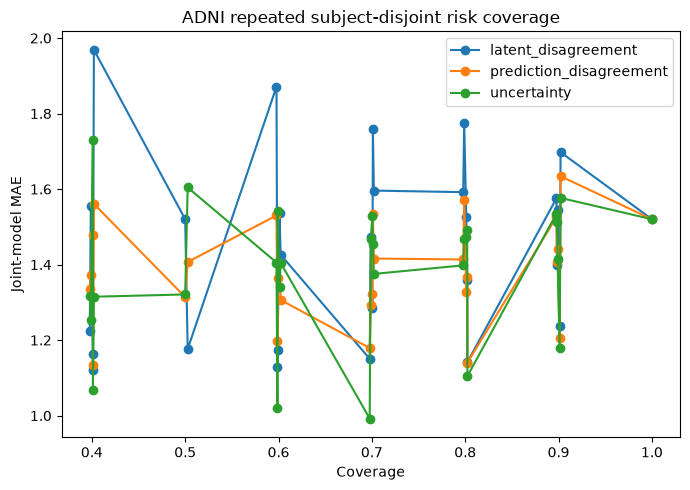

In [31]:
# ============================================================
# 25. RISK-COVERAGE SUMMARY
# ============================================================

risk_summary = (
    risk_coverage_repeated
    .groupby(
        [
            "signal",
            "coverage",
        ]
    )
    .agg(
        N_repeats=(
            "repeat",
            "count",
        ),
        MAE_mean=(
            "MAE",
            "mean",
        ),
        MAE_sd=(
            "MAE",
            "std",
        ),
        MAE_median=(
            "MAE",
            "median",
        ),
    )
    .reset_index()
)

display(
    risk_summary
)

plt.figure(
    figsize=(7, 5)
)

for signal, g in (
    risk_summary.groupby(
        "signal"
    )
):

    plt.plot(
        g["coverage"],
        g["MAE_median"],
        marker="o",
        label=signal,
    )

plt.xlabel(
    "Coverage"
)

plt.ylabel(
    "Joint-model MAE"
)

plt.title(
    "ADNI repeated subject-disjoint risk coverage"
)

plt.legend()
plt.tight_layout()
plt.show()


## 19. OASIS ↔ ADNI replication comparison


In [32]:
# ============================================================
# 26. OPTIONAL OASIS ↔ ADNI COMPARISON
# ============================================================

OASIS_ROOT = (
    OASIS_PROJECT_ROOT
    / "PAPER_READY_FINAL_RESULTS"
)

oasis_assoc_file = (
    OASIS_ROOT
    / "association_summary.csv"
)

oasis_perf_file = (
    OASIS_ROOT
    / "performance_summary.csv"
)

comparison_assoc_rows = []

if oasis_assoc_file.exists():

    oasis_assoc = pd.read_csv(
        oasis_assoc_file
    )

    for _, row in (
        oasis_assoc.iterrows()
    ):

        comparison_assoc_rows.append({
            "dataset":
                "OASIS-3",
            "signal":
                row["signal"],
            "rho_mean":
                row["rho_mean"],
            "rho_median":
                row["rho_median"],
            "fraction_positive":
                row[
                    "fraction_positive"
                ],
            "fraction_p_lt_05":
                row[
                    "fraction_p_lt_05"
                ],
        })

for _, row in (
    association_summary.iterrows()
):

    comparison_assoc_rows.append({
        "dataset":
            "ADNI",
        "signal":
            row["signal"],
        "rho_mean":
            row["rho_mean"],
        "rho_median":
            row["rho_median"],
        "fraction_positive":
            row[
                "fraction_positive"
            ],
        "fraction_p_lt_05":
            row[
                "fraction_p_lt_05"
            ],
    })

oasis_adni_association = (
    pd.DataFrame(
        comparison_assoc_rows
    )
)

if not oasis_adni_association.empty:

    display(
        oasis_adni_association
    )

    oasis_adni_association.to_csv(
        PAPER_ROOT
        / "oasis_adni_association_comparison.csv",
        index=False,
    )

comparison_perf_rows = []

if oasis_perf_file.exists():

    oasis_perf = pd.read_csv(
        oasis_perf_file
    )

    for _, row in (
        oasis_perf.iterrows()
    ):

        comparison_perf_rows.append({
            "dataset":
                "OASIS-3",
            "model":
                row["model"],
            "MAE_mean":
                row["MAE_mean"],
            "R2_mean":
                row["R2_mean"],
        })

for _, row in (
    performance_summary.iterrows()
):

    comparison_perf_rows.append({
        "dataset":
            "ADNI",
        "model":
            row["model"],
        "MAE_mean":
            row["MAE_mean"],
        "R2_mean":
            row["R2_mean"],
    })

oasis_adni_performance = (
    pd.DataFrame(
        comparison_perf_rows
    )
)

if not oasis_adni_performance.empty:

    display(
        oasis_adni_performance
    )

    oasis_adni_performance.to_csv(
        PAPER_ROOT
        / "oasis_adni_prediction_comparison.csv",
        index=False,
    )

print(
    "OASIS summary files found:",
    oasis_assoc_file.exists(),
    oasis_perf_file.exists(),
)


,dataset,signal,rho_mean,rho_median,fraction_positive,fraction_p_lt_05
0,OASIS-3,uncertainty,0.263138,0.205074,1.000000,0.166667
1,OASIS-3,prediction_disagreement,0.321127,0.302779,1.000000,0.500000
2,OASIS-3,latent_disagreement,0.059574,0.042057,0.500000,0.333333
3,OASIS-3,raw_view_spread,0.204294,0.195032,1.000000,0.166667
4,OASIS-3,clinical_view_spread,0.342042,0.342268,1.000000,0.500000
5,ADNI,uncertainty,0.347998,0.435194,0.833333,0.666667
6,ADNI,prediction_disagreement,0.211335,0.212762,1.000000,0.500000
7,ADNI,latent_disagreement,0.079407,0.065700,0.500000,0.333333
8,ADNI,raw_view_spread,-0.019684,-0.029589,0.500000,0.000000
9,ADNI,clinical_view_spread,0.470348,0.463121,1.000000,1.000000


,dataset,model,MAE_mean,R2_mean
0,OASIS-3,Clinical_branch,1.323709,0.478149
1,OASIS-3,Gated_joint,1.358416,0.488268
2,OASIS-3,MRI_branch,1.897154,-0.150284
3,OASIS-3,Persistence,1.353255,0.459312
4,ADNI,Clinical_branch,1.512419,0.767088
5,ADNI,Gated_joint,1.532579,0.768146
6,ADNI,MRI_branch,3.722313,-0.323301
7,ADNI,Persistence,1.637247,0.720375


OASIS summary files found: True True


## 20. Final ADNI evidence summary


In [33]:
# ============================================================
# 27. FINAL ADNI EVIDENCE SUMMARY
# ============================================================

cross = association_summary[
    association_summary[
        "signal"
    ].eq(
        "prediction_disagreement"
    )
]

unc = association_summary[
    association_summary[
        "signal"
    ].eq(
        "uncertainty"
    )
]

latent = association_summary[
    association_summary[
        "signal"
    ].eq(
        "latent_disagreement"
    )
]

print("=" * 80)
print("ADNI EXTERNAL VALIDATION EVIDENCE")
print("=" * 80)

print(
    "Final modeling subjects:",
    sequence_df[
        "subject_id"
    ].nunique(),
)

print(
    "Final modeling rows:",
    len(sequence_df),
)

if len(cross):

    r = cross.iloc[0]

    print(
        "\nCross-modal prediction disagreement:"
    )

    print(
        f"  mean rho     = {r['rho_mean']:.3f}"
    )

    print(
        f"  median rho   = {r['rho_median']:.3f}"
    )

    print(
        f"  positive     = {r['fraction_positive']:.2f}"
    )

    print(
        f"  p < .05      = {r['fraction_p_lt_05']:.2f}"
    )

if len(unc):

    r = unc.iloc[0]

    print(
        "\nEnsemble uncertainty:"
    )

    print(
        f"  mean rho     = {r['rho_mean']:.3f}"
    )

    print(
        f"  median rho   = {r['rho_median']:.3f}"
    )

    print(
        f"  positive     = {r['fraction_positive']:.2f}"
    )

if len(latent):

    r = latent.iloc[0]

    print(
        "\nLatent disagreement:"
    )

    print(
        f"  mean rho     = {r['rho_mean']:.3f}"
    )

    print(
        f"  median rho   = {r['rho_median']:.3f}"
    )

print(
    "\nInterpretation:"
)

print(
    "The ADNI result should be reported as an independent "
    "replication test. The key endpoint is the repeated-split "
    "association between cross-modal prediction disagreement "
    "and absolute prediction error."
)

print(
    "Prediction performance and reliability are separate "
    "questions. A multimodal predictor does not need to improve "
    "MAE over persistence or clinical history for the reliability "
    "hypothesis to be testable."
)

print(
    "Do not claim superiority over all uncertainty measures "
    "unless the observed ADNI effect sizes and statistical "
    "comparisons justify that claim."
)


ADNI EXTERNAL VALIDATION EVIDENCE
Final modeling subjects: 310
Final modeling rows: 934

Cross-modal prediction disagreement:
  mean rho     = 0.211
  median rho   = 0.213
  positive     = 1.00
  p < .05      = 0.50

Ensemble uncertainty:
  mean rho     = 0.348
  median rho   = 0.435
  positive     = 0.83

Latent disagreement:
  mean rho     = 0.079
  median rho   = 0.066

Interpretation:
The ADNI result should be reported as an independent replication test. The key endpoint is the repeated-split association between cross-modal prediction disagreement and absolute prediction error.
Prediction performance and reliability are separate questions. A multimodal predictor does not need to improve MAE over persistence or clinical history for the reliability hypothesis to be testable.
Do not claim superiority over all uncertainty measures unless the observed ADNI effect sizes and statistical comparisons justify that claim.


## 21. Final QC and saved outputs


In [34]:
# ============================================================
# 28. FINAL QC + SAVE EVERYTHING
# ============================================================

qc = {
    "selected_mri_series":
        int(len(selected)),
    "selected_mri_subjects":
        int(
            selected[
                "subject_id"
            ].nunique()
        ),
    "clinical_rows":
        int(len(clinical)),
    "clinical_subjects":
        int(
            clinical[
                "subject_id"
            ].nunique()
        ),
    "anchor_rows":
        int(len(anchors)),
    "anchor_subjects":
        int(
            anchors[
                "subject_id"
            ].nunique()
        ),
    "prediction_rows_final":
        int(
            len(
                prediction_cohort
            )
        ),
    "prediction_subjects_final":
        int(
            prediction_cohort[
                "subject_id"
            ].nunique()
        ),
    "verified_triadd_embeddings":
        int(
            len(
                embedding_manifest
            )
        ),
    "sequence_rows":
        int(
            len(
                sequence_df
            )
        ),
    "sequence_subjects":
        int(
            sequence_df[
                "subject_id"
            ].nunique()
        ),
    "outer_repeats":
        int(
            N_OUTER_REPEATS
        ),
    "subject_disjoint_outer_splits":
        True,
    "triad_frozen":
        True,
    "pca_fold_local":
        True,
    "clinical_history_uses_only_anchor_or_earlier":
        True,
    "test_outcomes_used_to_construct_reliability_scores":
        False,
    "freesurfer_benchmark":
        "not_run",
}

qc_df = pd.DataFrame(
    list(
        qc.items()
    ),
    columns=[
        "metric",
        "value",
    ],
)

display(
    qc_df
)

qc_df.to_csv(
    QC_DIR
    / "adni_final_qc_summary.csv",
    index=False,
)

config = {
    "seed":
        int(SEED),
    "target_shape":
        list(TARGET_SHAPE),
    "expected_embedding_dim":
        int(EXPECTED_EMBED_DIM),
    "mri_clinical_match_window_days":
        int(
            MRI_CLINICAL_MATCH_WINDOW_DAYS
        ),
    "min_future_days":
        int(MIN_FUTURE_DAYS),
    "max_future_days":
        int(MAX_FUTURE_DAYS),
    "max_mri_history":
        int(MAX_MRI_HISTORY),
    "max_clinical_history":
        int(MAX_CLINICAL_HISTORY),
    "clinical_features":
        CLINICAL_FEATURES,
    "pca_dim_raw":
        int(PCA_DIM_RAW),
    "temporal_hidden":
        int(TEMPORAL_HIDDEN),
    "batch_size":
        int(BATCH_SIZE),
    "max_epochs":
        int(MAX_EPOCHS),
    "patience":
        int(PATIENCE),
    "learning_rate":
        float(LEARNING_RATE),
    "weight_decay":
        float(WEIGHT_DECAY),
    "outer_test_size":
        float(OUTER_TEST_SIZE),
    "n_outer_repeats":
        int(N_OUTER_REPEATS),
    "n_inner_folds":
        int(N_INNER_FOLDS),
    "n_oof_members":
        int(N_OOF_MEMBERS),
    "n_test_members":
        int(N_TEST_MEMBERS),
    "fixed_large_error_threshold":
        float(
            FIXED_LARGE_ERROR_THRESHOLD
        ),
    "triad_checkpoint":
        str(TRIAD_CKPT),
}

with open(
    PAPER_ROOT
    / "analysis_config.json",
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        config,
        f,
        indent=2,
    )

save_tables = {
    "performance_repeated.csv":
        performance_repeated,
    "performance_summary.csv":
        performance_summary,
    "association_repeated.csv":
        association_repeated,
    "association_summary.csv":
        association_summary,
    "partial_association_repeated.csv":
        partial_repeated,
    "error_prediction_repeated.csv":
        error_prediction_repeated,
    "error_prediction_summary.csv":
        error_prediction_summary,
    "large_error_repeated.csv":
        large_error_repeated,
    "large_error_summary.csv":
        large_error_summary,
    "risk_coverage_repeated.csv":
        risk_coverage_repeated,
    "risk_coverage_summary.csv":
        risk_summary,
    "control_summary.csv":
        control_summary,
    "selected_mri_visits.csv":
        selected_mri,
    "embedding_manifest.csv":
        embedding_manifest,
    "prediction_cohort.csv":
        prediction_cohort[
            [
                "subject_id",
                "anchor_clinical_date",
                "mri_date",
                "anchor_mmse",
                "future_mmse",
                "future_interval_days",
                "mmse_change",
            ]
        ],
}

for fname, table in (
    save_tables.items()
):

    table.to_csv(
        PAPER_ROOT / fname,
        index=False,
    )

print("=" * 80)
print("ADNI PAPER-READY OUTPUTS")
print("=" * 80)
print(PAPER_ROOT)


,metric,value
0,selected_mri_series,1945
1,selected_mri_subjects,401
2,clinical_rows,13877
3,clinical_subjects,3891
4,anchor_rows,1097
5,anchor_subjects,336
6,prediction_rows_final,934
7,prediction_subjects_final,310
8,verified_triadd_embeddings,1756
9,sequence_rows,934


ADNI PAPER-READY OUTPUTS
C:\Projects\OASIS\ADNI\PAPER_READY_FINAL_RESULTS


# 22. Interpretation and manuscript guardrails

The ADNI analysis is intended as an **independent external replication** of the reliability phenomenon discovered in OASIS-3.

The strongest evidence is the stability of the continuous cross-modal disagreement ↔ absolute error relationship across subject-disjoint ADNI outer splits.

Do not use a simplistic PASS/FAIL gate. Report effect sizes, split-to-split variation, event counts for large-error classification, and the partial association.

Do not claim that:

- MRI improves future-MMSE prediction;
- gated multimodal fusion necessarily beats persistence or clinical history;
- cross-modal disagreement is superior to every uncertainty measure;
- latent disagreement is required for the effect;
- the ADNI result proves universality across all neurodegenerative datasets.

The intended final claim is narrow:

> **Cross-modal disagreement is a reproducible candidate signal of predictive unreliability across independently analyzed longitudinal MRI cohorts.**
